# Time Series Forecasting Training Notebook
## DATATHON 2026 - Revenue Prediction

**Objective:** Train time series forecasting model to predict daily Revenue for 2023-01-01 to 2024-07-01

**Key Requirements:**
- No data leakage
- Time-based train/validation/test split
- Features from master_table aggregated to daily level
- Lag and rolling features
- Baseline and advanced models
- Comprehensive evaluation with metrics and visualizations

## 0. Install Required Packages

**Note:** Run this cell first if packages are not installed. On Kaggle, most packages are pre-installed.

In [1]:
# ============================================================================
# INSTALL REQUIRED PACKAGES
# ============================================================================
# Uncomment and run this cell if packages are missing

!pip install --upgrade pip
!pip install pandas>=1.5.0
!pip install numpy>=1.23.0
!pip install matplotlib>=3.6.0
!pip install seaborn>=0.12.0
!pip install plotly>=5.11.0
!pip install scikit-learn>=1.2.0
!pip install lightgbm>=3.3.0
!pip install xgboost>=1.7.0
!pip install joblib>=1.2.0
!pip install scipy>=1.9.0

print("Package installation cell (currently commented out)")
print("Uncomment the lines above if you need to install packages")
print("On Kaggle, most packages are pre-installed and this step is optional")

Package installation cell (currently commented out)
Uncomment the lines above if you need to install packages
On Kaggle, most packages are pre-installed and this step is optional


## 1. Configuration and Imports

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================
import warnings
warnings.filterwarnings('ignore')

import random
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta

# Set random seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Path configuration
BASE_PATH = Path('../data')
RAW_PATH = BASE_PATH / 'raw'
OUTPUT_PATH = BASE_PATH / 'output'
MODEL_PATH = Path('../models')
MODEL_PATH.mkdir(exist_ok=True)

# Date split configuration
TRAIN_START = '2012-07-04'
TRAIN_END = '2021-12-31'
VAL_START = '2022-01-01'
VAL_END = '2022-12-31'
TEST_START = '2023-01-01'
TEST_END = '2024-07-01'

print(f"Random Seed: {RANDOM_SEED}")
print(f"Data Path: {BASE_PATH}")
print(f"Train Period: {TRAIN_START} to {TRAIN_END}")
print(f"Validation Period: {VAL_START} to {VAL_END}")
print(f"Test Period: {TEST_START} to {TEST_END}")

Random Seed: 42
Data Path: ..\data
Train Period: 2012-07-04 to 2021-12-31
Validation Period: 2022-01-01 to 2022-12-31
Test Period: 2023-01-01 to 2024-07-01


In [3]:
# ============================================================================
# IMPORTS
# ============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ML libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Gradient Boosting
import lightgbm as lgb
import xgboost as xgb

# Model persistence
import joblib

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("All imports successful!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"lightgbm: {lgb.__version__}")
print(f"xgboost: {xgb.__version__}")

All imports successful!
pandas: 3.0.2
numpy: 2.4.4
lightgbm: 4.6.0
xgboost: 3.2.0


## 2. Load Data

In [4]:
# ============================================================================
# LOAD DATA
# ============================================================================

# Load target data (daily revenue)
print("Loading sales.csv...")
sales_df = pd.read_csv(RAW_PATH / 'sales.csv', parse_dates=['Date'])
sales_df.rename(columns={'Date': 'date'}, inplace=True)
print(f"Sales shape: {sales_df.shape}")
print(f"Date range: {sales_df['date'].min()} to {sales_df['date'].max()}")
print(f"Columns: {sales_df.columns.tolist()}")

# Load sample submission to get test dates
print("\nLoading sample_submission.csv...")
submission_df = pd.read_csv(RAW_PATH / 'sample_submission.csv', parse_dates=['Date'])
submission_df.rename(columns={'Date': 'date'}, inplace=True)
print(f"Submission shape: {submission_df.shape}")
print(f"Test date range: {submission_df['date'].min()} to {submission_df['date'].max()}")

# Load master table (order_item level)
print("\nLoading master_table.csv...")
master_df = pd.read_csv(OUTPUT_PATH / 'master_table.csv')
print(f"Master table shape: {master_df.shape}")
print(f"Columns: {master_df.columns.tolist()[:10]}... (first 10)")

# Parse date columns in master_table
date_cols = ['order_date', 'payment_date', 'ship_date', 'delivery_date', 'return_date', 'review_date']
for col in date_cols:
    if col in master_df.columns:
        master_df[col] = pd.to_datetime(master_df[col], errors='coerce')

print(f"\nMaster table date range (order_date): {master_df['order_date'].min()} to {master_df['order_date'].max()}")
print(f"\nFirst few rows of sales:")
print(sales_df.head())
print(f"\nFirst few rows of master table:")
print(master_df.head())

Loading sales.csv...
Sales shape: (3833, 3)
Date range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00
Columns: ['date', 'Revenue', 'COGS']

Loading sample_submission.csv...
Submission shape: (548, 3)
Test date range: 2023-01-01 00:00:00 to 2024-07-01 00:00:00

Loading master_table.csv...
Master table shape: (714669, 53)
Columns: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2', 'order_item_id', 'line_revenue', 'order_date']... (first 10)

Master table date range (order_date): 2012-07-04 00:00:00 to 2022-12-31 00:00:00

First few rows of sales:
        date     Revenue        COGS
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79

First few rows of master table:
   order_id  product_id  quantity  unit_price  discount_amount  promo_id  \
0         1        2400         7     1138.22              0.0  NO_PROMO  

## 3. Data Validation and Exploration

In [5]:
# ============================================================================
# DATA VALIDATION
# ============================================================================

print("=" * 80)
print("SALES DATA VALIDATION")
print("=" * 80)

# Check for missing dates
date_range = pd.date_range(start=sales_df['date'].min(), end=sales_df['date'].max(), freq='D')
missing_dates = set(date_range) - set(sales_df['date'])
print(f"\nTotal dates in range: {len(date_range)}")
print(f"Dates in sales: {len(sales_df)}")
print(f"Missing dates: {len(missing_dates)}")

# Check for nulls
print(f"\nNull values in sales:")
print(sales_df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate dates in sales: {sales_df['date'].duplicated().sum()}")

# Summary statistics
print(f"\nSales summary statistics:")
print(sales_df.describe())

print("\n" + "=" * 80)
print("MASTER TABLE VALIDATION")
print("=" * 80)

# Check master table data types
print(f"\nMaster table data types:")
print(master_df.dtypes)

# Check null percentages
print(f"\nNull percentages in master table:")
null_pct = (master_df.isnull().sum() / len(master_df) * 100).sort_values(ascending=False)
print(null_pct[null_pct > 0].head(20))

# Check for negative values in revenue/cogs
if 'line_revenue' in master_df.columns:
    print(f"\nNegative line_revenue: {(master_df['line_revenue'] < 0).sum()}")
if 'line_cogs' in master_df.columns:
    print(f"Negative line_cogs: {(master_df['line_cogs'] < 0).sum()}")

SALES DATA VALIDATION

Total dates in range: 3833
Dates in sales: 3833
Missing dates: 0

Null values in sales:
date       0
Revenue    0
COGS       0
dtype: int64

Duplicate dates in sales: 0

Sales summary statistics:
                      date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.286584e+06  3.695134e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  2.090527e+07  1.653586e+07
std                    NaN  2.624840e+06  2.219789e+06

MASTER TABLE VALIDATION

Master table data types:
order_id                         int64
product_id                       int64
quantity                         int64
unit_price                     float64
discount_amount                float64
promo_id                           str
p

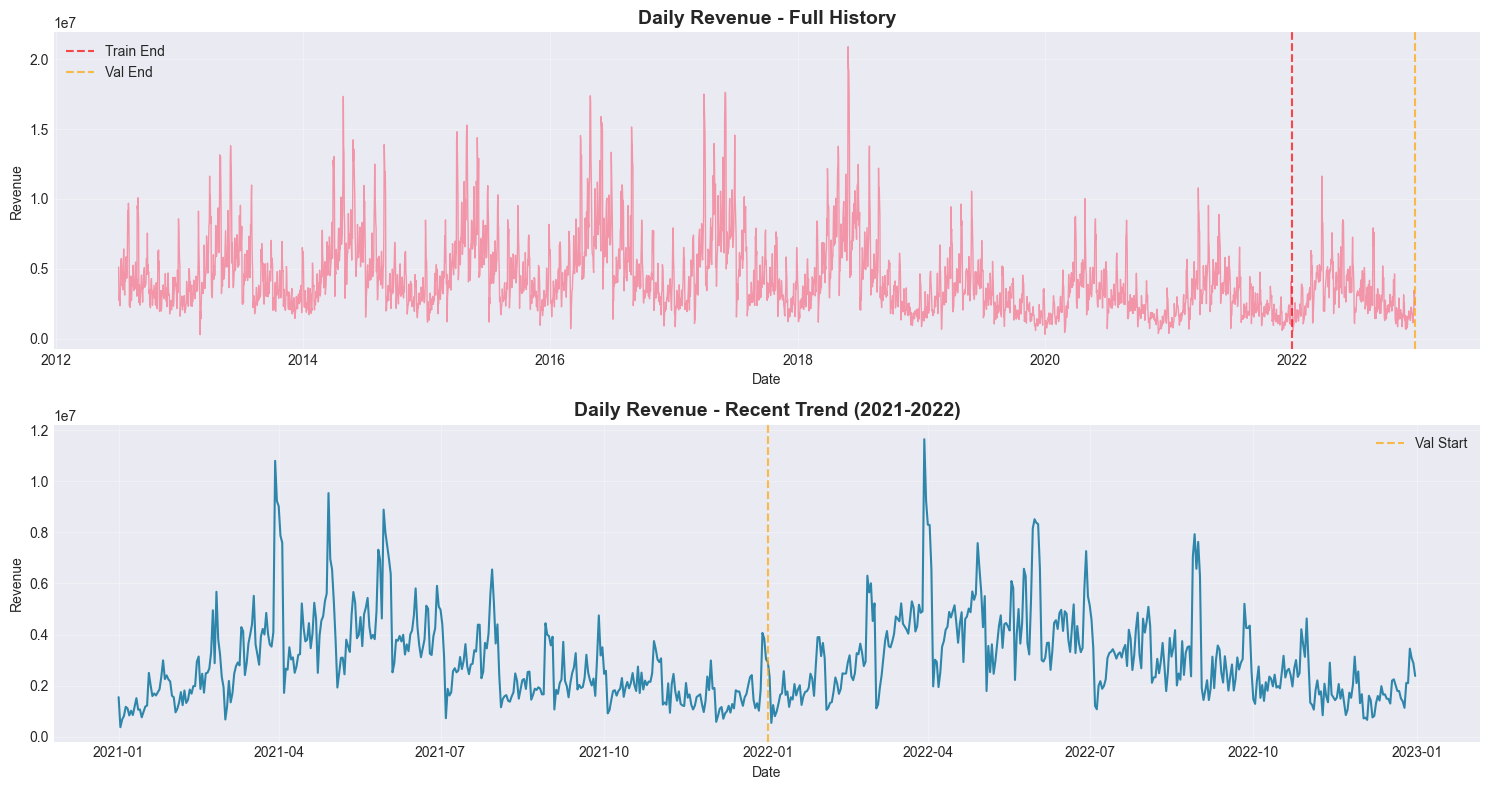

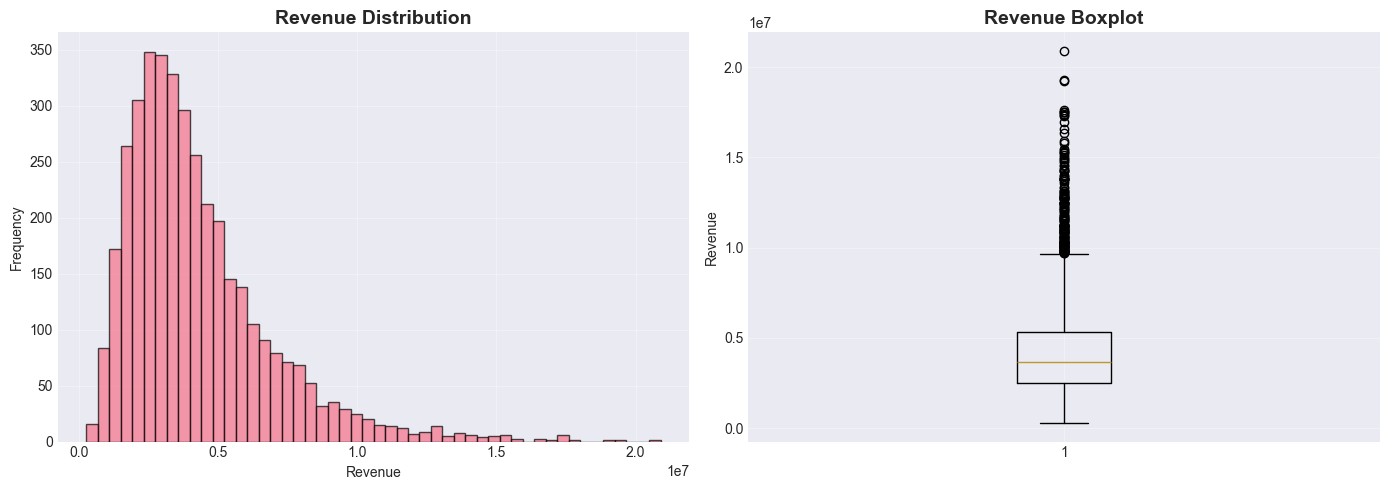

In [6]:
# ============================================================================
# EXPLORATORY VISUALIZATION
# ============================================================================

# Plot revenue time series
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Full time series
axes[0].plot(sales_df['date'], sales_df['Revenue'], linewidth=1, alpha=0.7)
axes[0].set_title('Daily Revenue - Full History', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue')
axes[0].grid(True, alpha=0.3)
axes[0].axvline(pd.to_datetime(TRAIN_END), color='red', linestyle='--', label='Train End', alpha=0.7)
axes[0].axvline(pd.to_datetime(VAL_END), color='orange', linestyle='--', label='Val End', alpha=0.7)
axes[0].legend()

# Recent trend (last 2 years)
recent_df = sales_df[sales_df['date'] >= '2021-01-01']
axes[1].plot(recent_df['date'], recent_df['Revenue'], linewidth=1.5, color='#2E86AB')
axes[1].set_title('Daily Revenue - Recent Trend (2021-2022)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Revenue')
axes[1].grid(True, alpha=0.3)
axes[1].axvline(pd.to_datetime(VAL_START), color='orange', linestyle='--', label='Val Start', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

# Distribution of Revenue
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sales_df['Revenue'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Revenue Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Revenue')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(sales_df['Revenue'])
axes[1].set_title('Revenue Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Revenue')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Feature Engineering

### 4.1 Aggregate Master Table to Daily Level

In [7]:
# ============================================================================
# AGGREGATE MASTER TABLE TO DAILY LEVEL
# ============================================================================

print("Aggregating master_table to daily level...")

# Filter master table to historical data only (before test period)
master_historical = master_df[master_df['order_date'] < TEST_START].copy()
print(f"Historical master table: {len(master_historical)} rows")
print(f"Date range: {master_historical['order_date'].min()} to {master_historical['order_date'].max()}")

# Aggregate numerical features
daily_features = master_historical.groupby('order_date').agg({
    'order_item_id': 'count',  # Number of order items
    'order_id': 'nunique',     # Number of unique orders
    'customer_id': 'nunique',  # Number of unique customers
    'product_id': 'nunique',   # Number of unique products
    'quantity': ['sum', 'mean', 'std'],
    'unit_price': ['mean', 'std', 'min', 'max'],
    'discount_amount': ['sum', 'mean', 'std'],
    'line_revenue': ['sum', 'mean', 'std'],
    'line_cogs': ['sum', 'mean', 'std'],
}).reset_index()

# Flatten column names
daily_features.columns = ['_'.join(col).strip('_') if col[1] else col[0] for col in daily_features.columns.values]
daily_features.rename(columns={'order_date': 'date'}, inplace=True)

print(f"\nDaily features shape: {daily_features.shape}")
print(f"Columns: {daily_features.columns.tolist()}")

# Aggregate categorical features
print("\nAggregating categorical features...")

# Category distribution
if 'category' in master_historical.columns:
    category_daily = master_historical.groupby(['order_date', 'category']).size().unstack(fill_value=0)
    category_daily.columns = [f'category_{col}_count' for col in category_daily.columns]
    category_daily = category_daily.reset_index()
    category_daily.rename(columns={'order_date': 'date'}, inplace=True)
    daily_features = daily_features.merge(category_daily, on='date', how='left')

# Segment distribution
if 'segment' in master_historical.columns:
    segment_daily = master_historical.groupby(['order_date', 'segment']).size().unstack(fill_value=0)
    segment_daily.columns = [f'segment_{col}_count' for col in segment_daily.columns]
    segment_daily = segment_daily.reset_index()
    segment_daily.rename(columns={'order_date': 'date'}, inplace=True)
    daily_features = daily_features.merge(segment_daily, on='date', how='left')

# Region distribution
if 'region' in master_historical.columns:
    region_daily = master_historical.groupby(['order_date', 'region']).size().unstack(fill_value=0)
    region_daily.columns = [f'region_{col}_count' for col in region_daily.columns]
    region_daily = region_daily.reset_index()
    region_daily.rename(columns={'order_date': 'date'}, inplace=True)
    daily_features = daily_features.merge(region_daily, on='date', how='left')

# Payment method distribution
if 'payment_method' in master_historical.columns:
    payment_daily = master_historical.groupby(['order_date', 'payment_method']).size().unstack(fill_value=0)
    payment_daily.columns = [f'payment_{col}_count' for col in payment_daily.columns]
    payment_daily = payment_daily.reset_index()
    payment_daily.rename(columns={'order_date': 'date'}, inplace=True)
    daily_features = daily_features.merge(payment_daily, on='date', how='left')

# Order source distribution
if 'order_source' in master_historical.columns:
    source_daily = master_historical.groupby(['order_date', 'order_source']).size().unstack(fill_value=0)
    source_daily.columns = [f'source_{col}_count' for col in source_daily.columns]
    source_daily = source_daily.reset_index()
    source_daily.rename(columns={'order_date': 'date'}, inplace=True)
    daily_features = daily_features.merge(source_daily, on='date', how='left')

# Calculate ratios and percentages
print("\nCalculating derived features...")

# Promo ratio
if 'promo_id' in master_historical.columns:
    promo_ratio = master_historical.groupby('order_date').apply(
        lambda x: (x['promo_id'].notna() & (x['promo_id'] != 'none')).sum() / len(x)
    ).reset_index()
    promo_ratio.columns = ['date', 'promo_ratio']
    daily_features = daily_features.merge(promo_ratio, on='date', how='left')

# Legacy ratio
if 'is_legacy' in master_historical.columns:
    legacy_ratio = master_historical.groupby('order_date')['is_legacy'].mean().reset_index()
    legacy_ratio.columns = ['date', 'legacy_ratio']
    daily_features = daily_features.merge(legacy_ratio, on='date', how='left')

# Return ratio (if available)
if 'order_status' in master_historical.columns:
    return_ratio = master_historical.groupby('order_date').apply(
        lambda x: (x['order_status'] == 'returned').sum() / len(x)
    ).reset_index()
    return_ratio.columns = ['date', 'return_ratio']
    daily_features = daily_features.merge(return_ratio, on='date', how='left')

# Review ratio
if 'review_id' in master_historical.columns:
    review_ratio = master_historical.groupby('order_date').apply(
        lambda x: (x['review_id'].notna() & (x['review_id'] != 0)).sum() / len(x)
    ).reset_index()
    review_ratio.columns = ['date', 'review_ratio']
    daily_features = daily_features.merge(review_ratio, on='date', how='left')

# Average items per order
daily_features['items_per_order'] = daily_features['order_item_id_count'] / daily_features['order_id_nunique']

# Average revenue per order
daily_features['revenue_per_order'] = daily_features['line_revenue_sum'] / daily_features['order_id_nunique']

# Average revenue per customer
daily_features['revenue_per_customer'] = daily_features['line_revenue_sum'] / daily_features['customer_id_nunique']

# Discount ratio
daily_features['discount_ratio'] = daily_features['discount_amount_sum'] / daily_features['line_revenue_sum']

# Fill any inf or nan from division
daily_features = daily_features.replace([np.inf, -np.inf], np.nan)
daily_features = daily_features.fillna(0)

print(f"\nFinal daily features shape: {daily_features.shape}")
print(f"Columns ({len(daily_features.columns)}): {daily_features.columns.tolist()[:20]}... (first 20)")
print(f"\nFirst few rows:")
print(daily_features.head())

Aggregating master_table to daily level...
Historical master table: 714669 rows
Date range: 2012-07-04 00:00:00 to 2022-12-31 00:00:00

Daily features shape: (3833, 21)
Columns: ['date', 'order_item_id_count', 'order_id_nunique', 'customer_id_nunique', 'product_id_nunique', 'quantity_sum', 'quantity_mean', 'quantity_std', 'unit_price_mean', 'unit_price_std', 'unit_price_min', 'unit_price_max', 'discount_amount_sum', 'discount_amount_mean', 'discount_amount_std', 'line_revenue_sum', 'line_revenue_mean', 'line_revenue_std', 'line_cogs_sum', 'line_cogs_mean', 'line_cogs_std']

Aggregating categorical features...

Calculating derived features...

Final daily features shape: (3833, 55)
Columns (55): ['date', 'order_item_id_count', 'order_id_nunique', 'customer_id_nunique', 'product_id_nunique', 'quantity_sum', 'quantity_mean', 'quantity_std', 'unit_price_mean', 'unit_price_std', 'unit_price_min', 'unit_price_max', 'discount_amount_sum', 'discount_amount_mean', 'discount_amount_std', 'line_r

### 4.2 Create Calendar Features

In [8]:
# ============================================================================
# CALENDAR FEATURES
# ============================================================================

def create_calendar_features(df, date_col='date'):
    """
    Create calendar-based features from date column.
    These features are safe for time series as they don't leak future information.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    
    # Basic date features
    df['year'] = df[date_col].dt.year
    df['month'] = df[date_col].dt.month
    df['day'] = df[date_col].dt.day
    df['day_of_week'] = df[date_col].dt.dayofweek  # 0 = Monday, 6 = Sunday
    df['day_of_year'] = df[date_col].dt.dayofyear
    df['week_of_year'] = df[date_col].dt.isocalendar().week
    df['quarter'] = df[date_col].dt.quarter
    
    # Cyclical encoding for seasonal patterns
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)
    
    # Boolean indicators
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_month_start'] = df[date_col].dt.is_month_start.astype(int)
    df['is_month_end'] = df[date_col].dt.is_month_end.astype(int)
    df['is_quarter_start'] = df[date_col].dt.is_quarter_start.astype(int)
    df['is_quarter_end'] = df[date_col].dt.is_quarter_end.astype(int)
    df['is_year_start'] = df[date_col].dt.is_year_start.astype(int)
    df['is_year_end'] = df[date_col].dt.is_year_end.astype(int)
    
    # Week of month (1-5)
    df['week_of_month'] = (df['day'] - 1) // 7 + 1
    
    return df

print("Creating calendar features for daily_features...")
daily_features = create_calendar_features(daily_features, 'date')

print(f"\nDaily features shape after calendar features: {daily_features.shape}")
print(f"\nNew calendar features:")
calendar_cols = [col for col in daily_features.columns if any(x in col for x in ['year', 'month', 'day', 'week', 'quarter', 'weekend', 'sin', 'cos'])]
print(calendar_cols)

Creating calendar features for daily_features...

Daily features shape after calendar features: (3833, 76)

New calendar features:
['segment_Everyday_count', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'week_of_year', 'quarter', 'month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_year_sin', 'day_of_year_cos', 'is_weekend', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'is_year_start', 'is_year_end', 'week_of_month']


### 4.3 Merge with Sales Target and Create Complete Date Range

In [9]:
# ============================================================================
# MERGE FEATURES WITH TARGET
# ============================================================================

print("Merging daily features with sales target...")

# Create complete date range for train + validation + test
all_dates = pd.date_range(start=TRAIN_START, end=TEST_END, freq='D')
df_all = pd.DataFrame({'date': all_dates})

print(f"Complete date range: {len(df_all)} days")

# Merge with sales (target)
df_all = df_all.merge(sales_df[['date', 'Revenue', 'COGS']], on='date', how='left')

# Merge with daily features
df_all = df_all.merge(daily_features, on='date', how='left')

# Add calendar features for all dates (including test)
df_all = create_calendar_features(df_all, 'date')

print(f"\nMerged data shape: {df_all.shape}")
print(f"Columns: {len(df_all.columns)}")

# Check target availability
print(f"\nTarget (Revenue) availability:")
print(f"  Non-null: {df_all['Revenue'].notna().sum()}")
print(f"  Null: {df_all['Revenue'].isna().sum()}")

# Check feature availability
print(f"\nFeature availability (order_item_id_count):")
print(f"  Non-null: {df_all['order_item_id_count'].notna().sum()}")
print(f"  Null: {df_all['order_item_id_count'].isna().sum()}")

# Forward fill features for missing dates (within reason)
# Note: Only fill features that come from master_table, not the target
feature_cols = [col for col in df_all.columns if col not in ['date', 'Revenue', 'COGS']]
df_all[feature_cols] = df_all[feature_cols].fillna(0)

print(f"\nAfter filling nulls:")
print(f"  Null counts: {df_all.isnull().sum().sum()}")

print(f"\nFirst few rows:")
print(df_all.head())

print(f"\nLast few rows:")
print(df_all.tail())

Merging daily features with sales target...
Complete date range: 4381 days

Merged data shape: (4381, 78)
Columns: 78

Target (Revenue) availability:
  Non-null: 3833
  Null: 548

Feature availability (order_item_id_count):
  Non-null: 3833
  Null: 548

After filling nulls:
  Null counts: 1096

First few rows:
        date     Revenue        COGS  order_item_id_count  order_id_nunique  \
0 2012-07-04  5123547.94  3982991.19                174.0             162.0   
1 2012-07-05  2751773.45  2150580.23                103.0              97.0   
2 2012-07-06  3054029.42  2517632.84                 99.0              93.0   
3 2012-07-07  2667930.94  2108246.62                 75.0              73.0   
4 2012-07-08  2360851.90  1808622.79                 94.0              88.0   

   customer_id_nunique  product_id_nunique  quantity_sum  quantity_mean  \
0                161.0                93.0         777.0       4.465517   
1                 97.0                65.0         428.0       

### 4.4 Create Lag and Rolling Features

In [10]:
# ============================================================================
# LAG AND ROLLING FEATURES
# ============================================================================

def create_lag_features(df, target_col, lags, date_col='date'):
    """
    Create lag features for a target column.
    IMPORTANT: This function assumes df is sorted by date.
    """
    df = df.copy()
    df = df.sort_values(date_col).reset_index(drop=True)
    
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    
    return df

def create_rolling_features(df, target_col, windows, date_col='date'):
    """
    Create rolling statistics features.
    IMPORTANT: This function assumes df is sorted by date.
    """
    df = df.copy()
    df = df.sort_values(date_col).reset_index(drop=True)
    
    for window in windows:
        # Rolling mean
        df[f'{target_col}_rolling_mean_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).mean()
        
        # Rolling std
        df[f'{target_col}_rolling_std_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).std()
        
        # Rolling min/max
        df[f'{target_col}_rolling_min_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).min()
        df[f'{target_col}_rolling_max_{window}'] = df[target_col].shift(1).rolling(window=window, min_periods=1).max()
    
    return df

def create_expanding_features(df, target_col, date_col='date'):
    """
    Create expanding window statistics.
    """
    df = df.copy()
    df = df.sort_values(date_col).reset_index(drop=True)
    
    df[f'{target_col}_expanding_mean'] = df[target_col].shift(1).expanding(min_periods=1).mean()
    df[f'{target_col}_expanding_std'] = df[target_col].shift(1).expanding(min_periods=1).std()
    
    return df

def create_diff_features(df, target_col, lags, date_col='date'):
    """
    Create difference features.
    """
    df = df.copy()
    df = df.sort_values(date_col).reset_index(drop=True)
    
    for lag in lags:
        df[f'{target_col}_diff_{lag}'] = df[target_col] - df[target_col].shift(lag)
    
    return df

print("Creating lag and rolling features...")
print("This may take a few moments...\n")

# Sort by date first
df_all = df_all.sort_values('date').reset_index(drop=True)

# Define lag periods (in days)
LAG_PERIODS = [1, 7, 14, 28, 56, 365]
ROLLING_WINDOWS = [7, 14, 28, 56, 365]
DIFF_PERIODS = [1, 7, 28, 365]

print(f"Creating lag features for Revenue...")
df_all = create_lag_features(df_all, 'Revenue', LAG_PERIODS, 'date')

print(f"Creating rolling features for Revenue...")
df_all = create_rolling_features(df_all, 'Revenue', ROLLING_WINDOWS, 'date')

print(f"Creating expanding features for Revenue...")
df_all = create_expanding_features(df_all, 'Revenue', 'date')

print(f"Creating difference features for Revenue...")
df_all = create_diff_features(df_all, 'Revenue', DIFF_PERIODS, 'date')

# Also create lag/rolling for key business metrics
print(f"\nCreating lag features for order_id_nunique...")
df_all = create_lag_features(df_all, 'order_id_nunique', [1, 7, 28], 'date')
df_all = create_rolling_features(df_all, 'order_id_nunique', [7, 28], 'date')

print(f"Creating lag features for customer_id_nunique...")
df_all = create_lag_features(df_all, 'customer_id_nunique', [1, 7, 28], 'date')
df_all = create_rolling_features(df_all, 'customer_id_nunique', [7, 28], 'date')

print(f"\nFinal dataset shape: {df_all.shape}")
print(f"Total features: {len(df_all.columns) - 3}  (excluding date, Revenue, COGS)")

# Check for any remaining nulls in features
feature_cols = [col for col in df_all.columns if col not in ['date', 'Revenue', 'COGS']]
null_counts = df_all[feature_cols].isnull().sum()
print(f"\nFeatures with nulls: {(null_counts > 0).sum()}")
if (null_counts > 0).any():
    print("\nTop features with nulls:")
    print(null_counts[null_counts > 0].sort_values(ascending=False).head(10))

Creating lag and rolling features...
This may take a few moments...

Creating lag features for Revenue...
Creating rolling features for Revenue...
Creating expanding features for Revenue...
Creating difference features for Revenue...

Creating lag features for order_id_nunique...
Creating lag features for customer_id_nunique...

Final dataset shape: (4381, 132)
Total features: 129  (excluding date, Revenue, COGS)

Features with nulls: 54

Top features with nulls:
Revenue_diff_365    913
Revenue_diff_28     576
Revenue_diff_7      555
Revenue_diff_1      549
Revenue_lag_1       548
Revenue_lag_7       548
Revenue_lag_14      548
Revenue_lag_28      548
Revenue_lag_56      548
Revenue_lag_365     548
dtype: int64


## 5. Train/Validation/Test Split

In [11]:
# ============================================================================
# TRAIN / VALIDATION / TEST SPLIT
# ============================================================================

print("Splitting data by time...")

# Convert split dates to datetime
train_start_dt = pd.to_datetime(TRAIN_START)
train_end_dt = pd.to_datetime(TRAIN_END)
val_start_dt = pd.to_datetime(VAL_START)
val_end_dt = pd.to_datetime(VAL_END)
test_start_dt = pd.to_datetime(TEST_START)
test_end_dt = pd.to_datetime(TEST_END)

# Split datasets
train_df = df_all[(df_all['date'] >= train_start_dt) & (df_all['date'] <= train_end_dt)].copy()
val_df = df_all[(df_all['date'] >= val_start_dt) & (df_all['date'] <= val_end_dt)].copy()
test_df = df_all[(df_all['date'] >= test_start_dt) & (df_all['date'] <= test_end_dt)].copy()

print(f"\nTrain set:")
print(f"  Shape: {train_df.shape}")
print(f"  Date range: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"  Non-null Revenue: {train_df['Revenue'].notna().sum()}")

print(f"\nValidation set:")
print(f"  Shape: {val_df.shape}")
print(f"  Date range: {val_df['date'].min()} to {val_df['date'].max()}")
print(f"  Non-null Revenue: {val_df['Revenue'].notna().sum()}")

print(f"\nTest set:")
print(f"  Shape: {test_df.shape}")
print(f"  Date range: {test_df['date'].min()} to {test_df['date'].max()}")
print(f"  Non-null Revenue: {test_df['Revenue'].notna().sum()}")

# Feature columns (exclude date and targets)
exclude_cols = ['date', 'Revenue', 'COGS']
feature_cols = [col for col in df_all.columns if col not in exclude_cols]

print(f"\nTotal feature columns: {len(feature_cols)}")

# Prepare X and y for train and validation
X_train = train_df[feature_cols].copy()
y_train = train_df['Revenue'].copy()

X_val = val_df[feature_cols].copy()
y_val = val_df['Revenue'].copy()

X_test = test_df[feature_cols].copy()

# Fill any remaining NaN in features with 0
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

# Replace inf values
X_train = X_train.replace([np.inf, -np.inf], 0)
X_val = X_val.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}")

# Verify no nulls or infs
print(f"\nX_train nulls: {X_train.isnull().sum().sum()}")
# Count inf values safely (numeric columns only)
x_train_num = X_train.select_dtypes(include=[np.number]).astype(np.float64)
print(f"X_train infs: {np.isinf(x_train_num.to_numpy()).sum()}")
print(f"y_train nulls: {y_train.isnull().sum()}")

Splitting data by time...

Train set:
  Shape: (3468, 132)
  Date range: 2012-07-04 00:00:00 to 2021-12-31 00:00:00
  Non-null Revenue: 3468

Validation set:
  Shape: (365, 132)
  Date range: 2022-01-01 00:00:00 to 2022-12-31 00:00:00
  Non-null Revenue: 365

Test set:
  Shape: (548, 132)
  Date range: 2023-01-01 00:00:00 to 2024-07-01 00:00:00
  Non-null Revenue: 0

Total feature columns: 129

X_train shape: (3468, 129)
y_train shape: (3468,)
X_val shape: (365, 129)
y_val shape: (365,)
X_test shape: (548, 129)

X_train nulls: 0
X_train infs: 0
y_train nulls: 0


In [12]:
# ============================================================================
# PREPARE DATA FOR REVENUE AND COGS PREDICTION
# ============================================================================

print("=" * 80)
print("PREPARING DATA FOR BOTH REVENUE AND COGS")
print("=" * 80)

# Prepare targets for Revenue
y_train_revenue = train_df['Revenue'].copy()
y_val_revenue = val_df['Revenue'].copy()

# Prepare targets for COGS
y_train_cogs = train_df['COGS'].copy()
y_val_cogs = val_df['COGS'].copy()

print(f"\nRevenue targets:")
print(f"  Train: {y_train_revenue.shape}, Non-null: {y_train_revenue.notna().sum()}")
print(f"  Val: {y_val_revenue.shape}, Non-null: {y_val_revenue.notna().sum()}")

print(f"\nCOGS targets:")
print(f"  Train: {y_train_cogs.shape}, Non-null: {y_train_cogs.notna().sum()}")
print(f"  Val: {y_val_cogs.shape}, Non-null: {y_val_cogs.notna().sum()}")

# Calculate Revenue/COGS ratio for reference
revenue_cogs_ratio = y_train_revenue / y_train_cogs
print(f"\nRevenue/COGS ratio statistics:")
print(f"  Mean: {revenue_cogs_ratio.mean():.4f}")
print(f"  Median: {revenue_cogs_ratio.median():.4f}")
print(f"  Std: {revenue_cogs_ratio.std():.4f}")

# For backward compatibility, keep y_train and y_val pointing to Revenue
y_train = y_train_revenue
y_val = y_val_revenue

PREPARING DATA FOR BOTH REVENUE AND COGS

Revenue targets:
  Train: (3468,), Non-null: 3468
  Val: (365,), Non-null: 365

COGS targets:
  Train: (3468,), Non-null: 3468
  Val: (365,), Non-null: 365

Revenue/COGS ratio statistics:
  Mean: 1.1638
  Median: 1.2225
  Std: 0.1346


### 5.1. Prepare Data for Both Revenue and COGS Prediction

**Note:** The submission requires both Revenue and COGS predictions.

## 6. Baseline Models

In [13]:
# ============================================================================
# BASELINE MODELS
# ============================================================================

def calculate_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate regression metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # MAPE (avoid division by zero)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.inf
    
    # R2
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Metrics:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  R²:   {r2:.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

print("="*80)
print("BASELINE MODELS")
print("="*80)

# Baseline 1: Naive - Last known value
print("\n1. Naive Baseline (Last Value)")
naive_pred_val = np.full(len(y_val), y_train.iloc[-1])
baseline_naive = calculate_metrics(y_val, naive_pred_val, "Naive (Last Value)")

# Baseline 2: Moving Average (7 days)
print("\n2. Moving Average Baseline (7 days)")
ma_7 = y_train.rolling(window=7).mean().iloc[-1]
ma_pred_val = np.full(len(y_val), ma_7)
baseline_ma7 = calculate_metrics(y_val, ma_pred_val, "Moving Average (7d)")

# Baseline 3: Moving Average (28 days)
print("\n3. Moving Average Baseline (28 days)")
ma_28 = y_train.rolling(window=28).mean().iloc[-1]
ma_pred_val = np.full(len(y_val), ma_28)
baseline_ma28 = calculate_metrics(y_val, ma_pred_val, "Moving Average (28d)")

# Baseline 4: Seasonal Naive (same day of week last year)
print("\n4. Seasonal Naive Baseline (same day last year)")
# Use 364 days ago (closest to 1 year with same day of week)
seasonal_pred_val = []
for idx in val_df.index:
    current_date = val_df.loc[idx, 'date']
    last_year_date = current_date - pd.Timedelta(days=364)
    
    # Find closest date in train
    if last_year_date in train_df['date'].values:
        pred_value = train_df[train_df['date'] == last_year_date]['Revenue'].values[0]
    else:
        # Use overall mean if not found
        pred_value = y_train.mean()
    
    seasonal_pred_val.append(pred_value)

seasonal_pred_val = np.array(seasonal_pred_val)
baseline_seasonal = calculate_metrics(y_val, seasonal_pred_val, "Seasonal Naive (364d)")

# Store baseline results
baseline_results = {
    'Naive (Last Value)': baseline_naive,
    'Moving Average (7d)': baseline_ma7,
    'Moving Average (28d)': baseline_ma28,
    'Seasonal Naive (364d)': baseline_seasonal
}

# Create baseline comparison dataframe
baseline_comparison = pd.DataFrame(baseline_results).T
print("\n" + "="*80)
print("BASELINE COMPARISON")
print("="*80)
print(baseline_comparison)

BASELINE MODELS

1. Naive Baseline (Last Value)

Naive (Last Value) Metrics:
  MAE:  1,280,665.20
  RMSE: 1,681,784.91
  MAPE: 51.71%
  R²:   -0.0096

2. Moving Average Baseline (7 days)

Moving Average (7d) Metrics:
  MAE:  1,355,788.10
  RMSE: 1,891,458.08
  MAPE: 42.30%
  R²:   -0.2770

3. Moving Average Baseline (28 days)

Moving Average (28d) Metrics:
  MAE:  1,678,696.33
  RMSE: 2,288,796.60
  MAPE: 44.50%
  R²:   -0.8698

4. Seasonal Naive Baseline (same day last year)

Seasonal Naive (364d) Metrics:
  MAE:  863,699.01
  RMSE: 1,247,488.43
  MAPE: 27.64%
  R²:   0.4445

BASELINE COMPARISON
                                MAE          RMSE       MAPE        R2
Naive (Last Value)     1.280665e+06  1.681785e+06  51.714079 -0.009552
Moving Average (7d)    1.355788e+06  1.891458e+06  42.302400 -0.276971
Moving Average (28d)   1.678696e+06  2.288797e+06  44.497755 -0.869830
Seasonal Naive (364d)  8.636990e+05  1.247488e+06  27.637771  0.444530


## 7. LightGBM Model Training

In [14]:
# ============================================================================
# LIGHTGBM MODEL
# ============================================================================

print("="*80)
print("LIGHTGBM MODEL TRAINING")
print("="*80)

# Create LightGBM datasets
print("\nCreating LightGBM datasets...")
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# LightGBM parameters
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': -1,
    'min_child_samples': 20,
    'verbose': -1,
    'seed': RANDOM_SEED,
    'n_jobs': -1
}

print("\nLightGBM Parameters:")
for key, value in lgb_params.items():
    print(f"  {key}: {value}")

# Train LightGBM
print("\nTraining LightGBM model...")
lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {lgb_model.best_iteration}")

# Predictions
print("\nMaking predictions...")
lgb_pred_train = lgb_model.predict(X_train, num_iteration=lgb_model.best_iteration)
lgb_pred_val = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration)
lgb_pred_test = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)

# Evaluate on train
lgb_metrics_train = calculate_metrics(y_train, lgb_pred_train, "LightGBM (Train)")

# Evaluate on validation
lgb_metrics_val = calculate_metrics(y_val, lgb_pred_val, "LightGBM (Validation)")

# Save model
lgb_model_path = MODEL_PATH / 'lightgbm_revenue_model.txt'
lgb_model.save_model(str(lgb_model_path))
print(f"\nModel saved to: {lgb_model_path}")

LIGHTGBM MODEL TRAINING

Creating LightGBM datasets...

LightGBM Parameters:
  objective: regression
  metric: rmse
  boosting_type: gbdt
  num_leaves: 31
  learning_rate: 0.05
  feature_fraction: 0.8
  bagging_fraction: 0.8
  bagging_freq: 5
  max_depth: -1
  min_child_samples: 20
  verbose: -1
  seed: 42
  n_jobs: -1

Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 100764	valid's rmse: 58078.1
[200]	train's rmse: 67553	valid's rmse: 54629.3
[300]	train's rmse: 55347.4	valid's rmse: 53725.5
Early stopping, best iteration is:
[301]	train's rmse: 55251.1	valid's rmse: 53700.9

Best iteration: 301

Making predictions...

LightGBM (Train) Metrics:
  MAE:  20,539.92
  RMSE: 55,251.04
  MAPE: 0.59%
  R²:   0.9996

LightGBM (Validation) Metrics:
  MAE:  35,756.17
  RMSE: 53,700.92
  MAPE: 1.26%
  R²:   0.9990

Model saved to: ..\models\lightgbm_revenue_model.txt


## 8. XGBoost Model Training

In [15]:
# ============================================================================
# XGBOOST MODEL
# ============================================================================

print("="*80)
print("XGBOOST MODEL TRAINING")
print("="*80)

# Create XGBoost DMatrix
print("\nCreating XGBoost DMatrix...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

# XGBoost parameters
xgb_params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'alpha': 0,
    'lambda': 1,
    'seed': RANDOM_SEED,
    'tree_method': 'hist',
    'verbosity': 1
}

print("\nXGBoost Parameters:")
for key, value in xgb_params.items():
    print(f"  {key}: {value}")

# Train XGBoost
print("\nTraining XGBoost model...")
evallist = [(dtrain, 'train'), (dval, 'valid')]

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=1000,
    evals=evallist,
    early_stopping_rounds=50,
    verbose_eval=100
)

print(f"\nBest iteration: {xgb_model.best_iteration}")

# Predictions
print("\nMaking predictions...")
xgb_pred_train = xgb_model.predict(dtrain, iteration_range=(0, xgb_model.best_iteration + 1))
xgb_pred_val = xgb_model.predict(dval, iteration_range=(0, xgb_model.best_iteration + 1))
xgb_pred_test = xgb_model.predict(dtest, iteration_range=(0, xgb_model.best_iteration + 1))

# Evaluate on train
xgb_metrics_train = calculate_metrics(y_train, xgb_pred_train, "XGBoost (Train)")

# Evaluate on validation
xgb_metrics_val = calculate_metrics(y_val, xgb_pred_val, "XGBoost (Validation)")

# Save model
xgb_model_path = MODEL_PATH / 'xgboost_revenue_model.json'
xgb_model.save_model(str(xgb_model_path))
print(f"\nModel saved to: {xgb_model_path}")

XGBOOST MODEL TRAINING

Creating XGBoost DMatrix...

XGBoost Parameters:
  objective: reg:squarederror
  eval_metric: rmse
  max_depth: 6
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 3
  gamma: 0
  alpha: 0
  lambda: 1
  seed: 42
  tree_method: hist
  verbosity: 1

Training XGBoost model...
[0]	train-rmse:2550058.54324	valid-rmse:1954819.85997
[100]	train-rmse:47571.90419	valid-rmse:40751.30149
[200]	train-rmse:26576.13956	valid-rmse:35469.68122
[268]	train-rmse:22612.71779	valid-rmse:35516.76579

Best iteration: 218

Making predictions...

XGBoost (Train) Metrics:
  MAE:  17,383.28
  RMSE: 25,379.40
  MAPE: 0.50%
  R²:   0.9999

XGBoost (Validation) Metrics:
  MAE:  23,750.85
  RMSE: 35,408.12
  MAPE: 0.87%
  R²:   0.9996

Model saved to: ..\models\xgboost_revenue_model.json


In [16]:
# ============================================================================
# TRAIN MODELS FOR COGS PREDICTION
# ============================================================================

print("=" * 80)
print("TRAINING MODELS FOR COGS PREDICTION")
print("=" * 80)

# -------------------------
# LightGBM for COGS
# -------------------------
print("\n1. Training LightGBM for COGS...")

lgb_train_cogs = lgb.Dataset(X_train, label=y_train_cogs)
lgb_val_cogs = lgb.Dataset(X_val, label=y_val_cogs, reference=lgb_train_cogs)

lgb_model_cogs = lgb.train(
    lgb_params,
    lgb_train_cogs,
    num_boost_round=1000,
    valid_sets=[lgb_train_cogs, lgb_val_cogs],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Best iteration: {lgb_model_cogs.best_iteration}")

# Predictions
lgb_pred_train_cogs = lgb_model_cogs.predict(X_train, num_iteration=lgb_model_cogs.best_iteration)
lgb_pred_val_cogs = lgb_model_cogs.predict(X_val, num_iteration=lgb_model_cogs.best_iteration)
lgb_pred_test_cogs = lgb_model_cogs.predict(X_test, num_iteration=lgb_model_cogs.best_iteration)

# Evaluate
lgb_metrics_train_cogs = calculate_metrics(y_train_cogs, lgb_pred_train_cogs, "LightGBM COGS (Train)")
lgb_metrics_val_cogs = calculate_metrics(y_val_cogs, lgb_pred_val_cogs, "LightGBM COGS (Validation)")

# Save model
lgb_cogs_model_path = MODEL_PATH / 'lightgbm_cogs_model.txt'
lgb_model_cogs.save_model(str(lgb_cogs_model_path))
print(f"\nCOGS model saved to: {lgb_cogs_model_path}")

# -------------------------
# XGBoost for COGS
# -------------------------
print("\n2. Training XGBoost for COGS...")

dtrain_cogs = xgb.DMatrix(X_train, label=y_train_cogs)
dval_cogs = xgb.DMatrix(X_val, label=y_val_cogs)
dtest_cogs = xgb.DMatrix(X_test)

xgb_model_cogs = xgb.train(
    xgb_params,
    dtrain_cogs,
    num_boost_round=1000,
    evals=[(dtrain_cogs, 'train'), (dval_cogs, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)

print(f"Best iteration: {xgb_model_cogs.best_iteration}")

# Predictions
xgb_pred_train_cogs = xgb_model_cogs.predict(dtrain_cogs, iteration_range=(0, xgb_model_cogs.best_iteration + 1))
xgb_pred_val_cogs = xgb_model_cogs.predict(dval_cogs, iteration_range=(0, xgb_model_cogs.best_iteration + 1))
xgb_pred_test_cogs = xgb_model_cogs.predict(dtest_cogs, iteration_range=(0, xgb_model_cogs.best_iteration + 1))

# Evaluate
xgb_metrics_train_cogs = calculate_metrics(y_train_cogs, xgb_pred_train_cogs, "XGBoost COGS (Train)")
xgb_metrics_val_cogs = calculate_metrics(y_val_cogs, xgb_pred_val_cogs, "XGBoost COGS (Validation)")

# Save model
xgb_cogs_model_path = MODEL_PATH / 'xgboost_cogs_model.json'
xgb_model_cogs.save_model(str(xgb_cogs_model_path))
print(f"\nCOGS model saved to: {xgb_cogs_model_path}")

# -------------------------
# Ensemble for COGS
# -------------------------
print("\n3. Creating ensemble for COGS...")
ensemble_pred_val_cogs = (lgb_pred_val_cogs + xgb_pred_val_cogs) / 2
ensemble_pred_test_cogs = (lgb_pred_test_cogs + xgb_pred_test_cogs) / 2

ensemble_metrics_val_cogs = calculate_metrics(y_val_cogs, ensemble_pred_val_cogs, "Ensemble COGS (Validation)")

# Comparison
print("\n" + "=" * 80)
print("COGS MODEL COMPARISON")
print("=" * 80)

cogs_results = {
    'LightGBM': lgb_metrics_val_cogs,
    'XGBoost': xgb_metrics_val_cogs,
    'Ensemble': ensemble_metrics_val_cogs
}

cogs_comparison_df = pd.DataFrame(cogs_results).T
cogs_comparison_df = cogs_comparison_df.sort_values('RMSE')

print("\nCOGS Validation Performance:")
print(cogs_comparison_df.to_string())

# Save comparison
cogs_comparison_path = OUTPUT_PATH / 'cogs_model_comparison.csv'
cogs_comparison_df.to_csv(cogs_comparison_path)
print(f"\nCOGS comparison saved to: {cogs_comparison_path}")

TRAINING MODELS FOR COGS PREDICTION

1. Training LightGBM for COGS...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 71229.9	valid's rmse: 65340.3
[200]	train's rmse: 49370.2	valid's rmse: 52332.9
[300]	train's rmse: 39458.9	valid's rmse: 51513.5
[400]	train's rmse: 32645.2	valid's rmse: 50399
Early stopping, best iteration is:
[384]	train's rmse: 33568.2	valid's rmse: 50219.1
Best iteration: 384

LightGBM COGS (Train) Metrics:
  MAE:  11,345.71
  RMSE: 33,568.21
  MAPE: 0.37%
  R²:   0.9998

LightGBM COGS (Validation) Metrics:
  MAE:  29,054.71
  RMSE: 50,219.14
  MAPE: 1.09%
  R²:   0.9988

COGS model saved to: ..\models\lightgbm_cogs_model.txt

2. Training XGBoost for COGS...
[0]	train-rmse:2155926.30278	valid-rmse:1682219.11646
[100]	train-rmse:40634.41408	valid-rmse:76535.30080
[200]	train-rmse:22714.03825	valid-rmse:65426.32495
[300]	train-rmse:18023.42004	valid-rmse:63510.67395
[400]	train-rmse:13533.08930	valid-rmse:62047.23305
[500]	train-rmse

## 8.5. Train Models for COGS Prediction

**Goal:** Train LightGBM and XGBoost models to predict COGS using the same features.

## 9. Model Comparison and Ensemble

In [17]:
# ============================================================================
# MODEL COMPARISON
# ============================================================================

print("="*80)
print("MODEL COMPARISON")
print("="*80)

# Compile all validation results
all_results = {
    'Naive (Last Value)': baseline_naive,
    'Moving Average (7d)': baseline_ma7,
    'Moving Average (28d)': baseline_ma28,
    'Seasonal Naive (364d)': baseline_seasonal,
    'LightGBM': lgb_metrics_val,
    'XGBoost': xgb_metrics_val
}

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df.sort_values('RMSE')

print("\nValidation Set Performance:")
print(comparison_df.to_string())

# Find best model
best_model_name = comparison_df.index[0]
print(f"\n{'='*80}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*80}")

# Create ensemble (simple average of LightGBM and XGBoost)
print("\nCreating ensemble (average of LightGBM and XGBoost)...")
ensemble_pred_val = (lgb_pred_val + xgb_pred_val) / 2
ensemble_pred_test = (lgb_pred_test + xgb_pred_test) / 2

ensemble_metrics_val = calculate_metrics(y_val, ensemble_pred_val, "Ensemble (Validation)")

# Add ensemble to comparison
all_results['Ensemble (LGB+XGB)'] = ensemble_metrics_val
comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df.sort_values('RMSE')

print("\nUpdated Validation Set Performance (with Ensemble):")
print(comparison_df.to_string())

# Save comparison table
comparison_path = OUTPUT_PATH / 'model_comparison.csv'
comparison_df.to_csv(comparison_path)
print(f"\nComparison table saved to: {comparison_path}")

MODEL COMPARISON

Validation Set Performance:
                                MAE          RMSE       MAPE        R2
XGBoost                2.375085e+04  3.540812e+04   0.868740  0.999552
LightGBM               3.575617e+04  5.370092e+04   1.256346  0.998971
Seasonal Naive (364d)  8.636990e+05  1.247488e+06  27.637771  0.444530
Naive (Last Value)     1.280665e+06  1.681785e+06  51.714079 -0.009552
Moving Average (7d)    1.355788e+06  1.891458e+06  42.302400 -0.276971
Moving Average (28d)   1.678696e+06  2.288797e+06  44.497755 -0.869830

BEST MODEL: XGBoost

Creating ensemble (average of LightGBM and XGBoost)...

Ensemble (Validation) Metrics:
  MAE:  25,627.15
  RMSE: 37,614.86
  MAPE: 0.89%
  R²:   0.9995

Updated Validation Set Performance (with Ensemble):
                                MAE          RMSE       MAPE        R2
XGBoost                2.375085e+04  3.540812e+04   0.868740  0.999552
Ensemble (LGB+XGB)     2.562715e+04  3.761486e+04   0.891421  0.999495
LightGBM         

## 10. Feature Importance Analysis

FEATURE IMPORTANCE ANALYSIS

Top 20 Features (LightGBM - Gain):
                  feature   importance
         line_revenue_sum 1.061785e+17
            line_cogs_sum 5.382076e+16
category_Streetwear_count 3.431669e+16
      discount_amount_sum 1.105036e+15
           unit_price_std 1.098616e+15
      customer_id_nunique 6.249281e+14
         line_revenue_std 5.405391e+14
        region_EAST_count 5.363498e+14
segment_Performance_count 4.456108e+14
        revenue_per_order 3.689835e+14
             quantity_sum 3.244113e+14
     discount_amount_mean 2.688060e+14
     revenue_per_customer 2.437761e+14
      order_item_id_count 1.656209e+14
         order_id_nunique 1.636204e+14
payment_credit_card_count 1.368252e+14
        line_revenue_mean 1.214946e+14
          unit_price_mean 9.371930e+13
   segment_Everyday_count 9.020878e+13
source_social_media_count 7.910826e+13

Top 20 Features (XGBoost - Gain):
                  feature   importance
         line_revenue_sum 1.253209e+14
cate

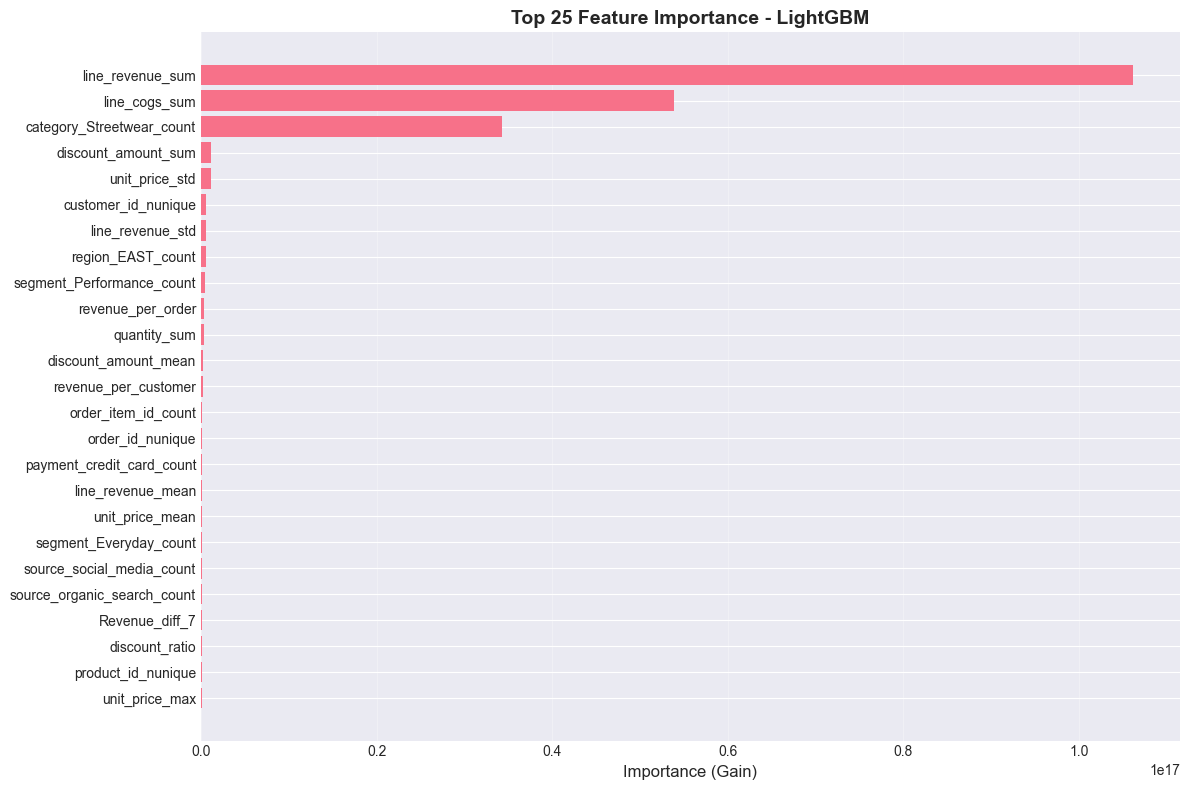


LightGBM feature importance saved to: ..\data\output\feature_importance_lgb.csv
XGBoost feature importance saved to: ..\data\output\feature_importance_xgb.csv


In [18]:
# ============================================================================
# FEATURE IMPORTANCE
# ============================================================================

print("="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

# Get feature importance from LightGBM
lgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

print("\nTop 20 Features (LightGBM - Gain):")
print(lgb_importance.head(20).to_string(index=False))

# Get feature importance from XGBoost
xgb_importance_dict = xgb_model.get_score(importance_type='gain')
xgb_importance = pd.DataFrame([
    {'feature': k, 'importance': v} for k, v in xgb_importance_dict.items()
]).sort_values('importance', ascending=False)

print("\nTop 20 Features (XGBoost - Gain):")
print(xgb_importance.head(20).to_string(index=False))

# Plot feature importance (LightGBM)
fig, ax = plt.subplots(figsize=(12, 8))
top_n = 25
lgb_importance_top = lgb_importance.head(top_n)

ax.barh(range(len(lgb_importance_top)), lgb_importance_top['importance'])
ax.set_yticks(range(len(lgb_importance_top)))
ax.set_yticklabels(lgb_importance_top['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance (Gain)', fontsize=12)
ax.set_title(f'Top {top_n} Feature Importance - LightGBM', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Save feature importance
lgb_importance_path = OUTPUT_PATH / 'feature_importance_lgb.csv'
lgb_importance.to_csv(lgb_importance_path, index=False)
print(f"\nLightGBM feature importance saved to: {lgb_importance_path}")

xgb_importance_path = OUTPUT_PATH / 'feature_importance_xgb.csv'
xgb_importance.to_csv(xgb_importance_path, index=False)
print(f"XGBoost feature importance saved to: {xgb_importance_path}")

## 11. Predictions Visualization

Creating visualization of predictions...


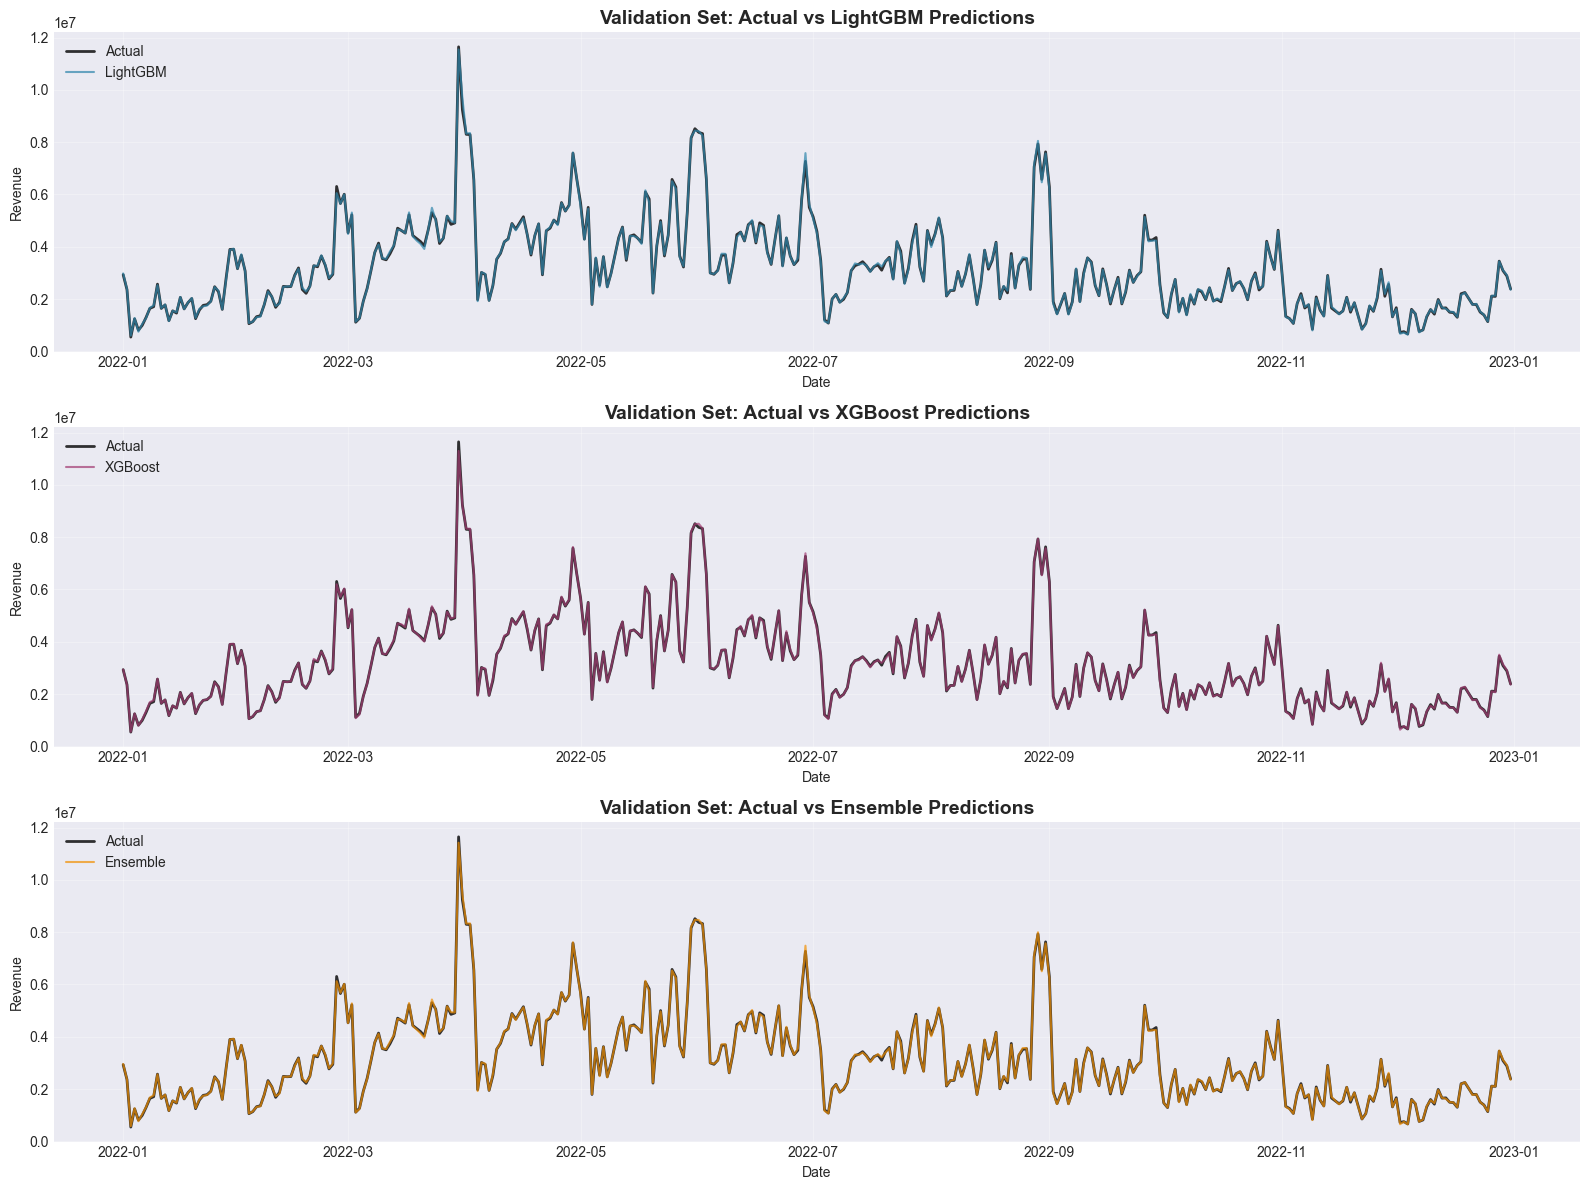

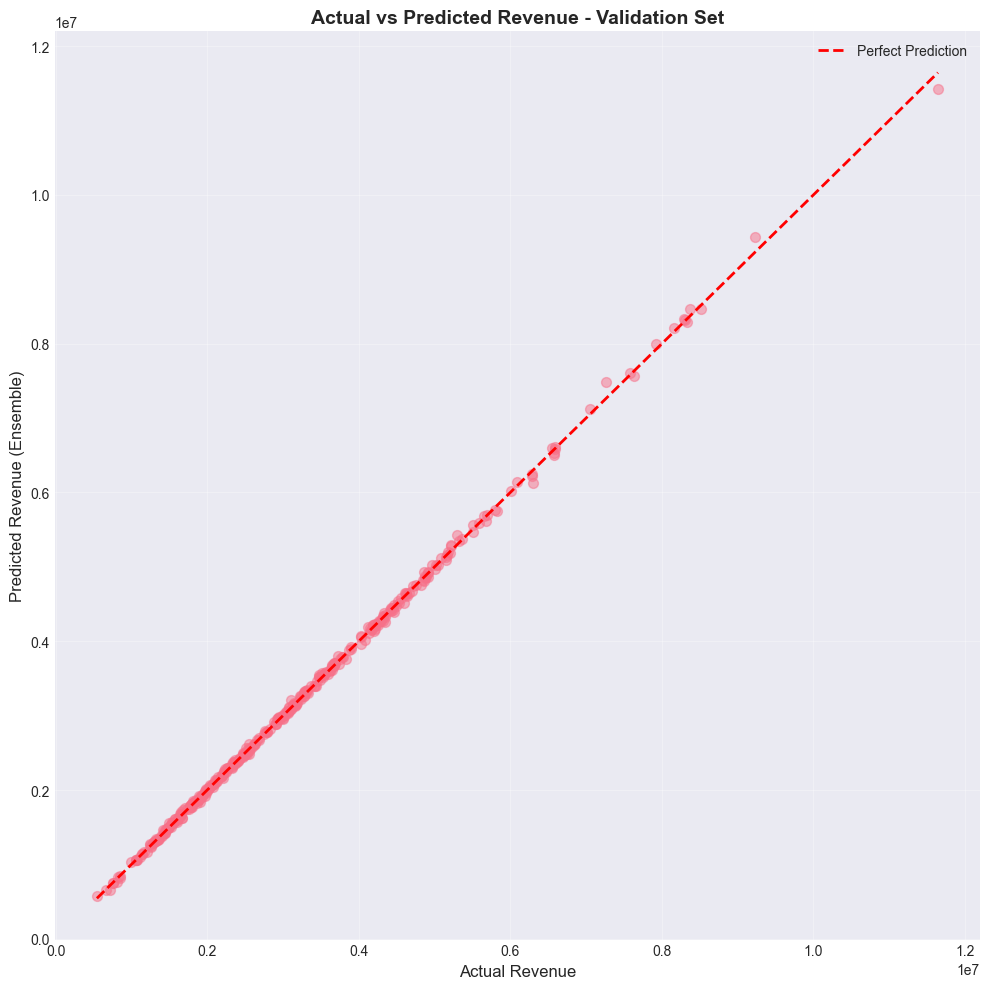

In [19]:
# ============================================================================
# ACTUAL VS PREDICTED VISUALIZATION
# ============================================================================

print("Creating visualization of predictions...")

# Prepare data for plotting
val_plot_df = val_df[['date']].copy()
val_plot_df['Actual'] = y_val.values
val_plot_df['LightGBM'] = lgb_pred_val
val_plot_df['XGBoost'] = xgb_pred_val
val_plot_df['Ensemble'] = ensemble_pred_val

# Plot actual vs predicted
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# LightGBM
axes[0].plot(val_plot_df['date'], val_plot_df['Actual'], label='Actual', linewidth=2, alpha=0.8, color='black')
axes[0].plot(val_plot_df['date'], val_plot_df['LightGBM'], label='LightGBM', linewidth=1.5, alpha=0.7, color='#2E86AB')
axes[0].set_title('Validation Set: Actual vs LightGBM Predictions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Revenue')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].plot(val_plot_df['date'], val_plot_df['Actual'], label='Actual', linewidth=2, alpha=0.8, color='black')
axes[1].plot(val_plot_df['date'], val_plot_df['XGBoost'], label='XGBoost', linewidth=1.5, alpha=0.7, color='#A23B72')
axes[1].set_title('Validation Set: Actual vs XGBoost Predictions', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Revenue')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Ensemble
axes[2].plot(val_plot_df['date'], val_plot_df['Actual'], label='Actual', linewidth=2, alpha=0.8, color='black')
axes[2].plot(val_plot_df['date'], val_plot_df['Ensemble'], label='Ensemble', linewidth=1.5, alpha=0.7, color='#F18F01')
axes[2].set_title('Validation Set: Actual vs Ensemble Predictions', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Revenue')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Scatter plot: Actual vs Predicted (Ensemble)
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(val_plot_df['Actual'], val_plot_df['Ensemble'], alpha=0.5, s=50)

# Add diagonal line (perfect prediction)
min_val = min(val_plot_df['Actual'].min(), val_plot_df['Ensemble'].min())
max_val = max(val_plot_df['Actual'].max(), val_plot_df['Ensemble'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual Revenue', fontsize=12)
ax.set_ylabel('Predicted Revenue (Ensemble)', fontsize=12)
ax.set_title('Actual vs Predicted Revenue - Validation Set', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Residual Analysis

Performing residual analysis...


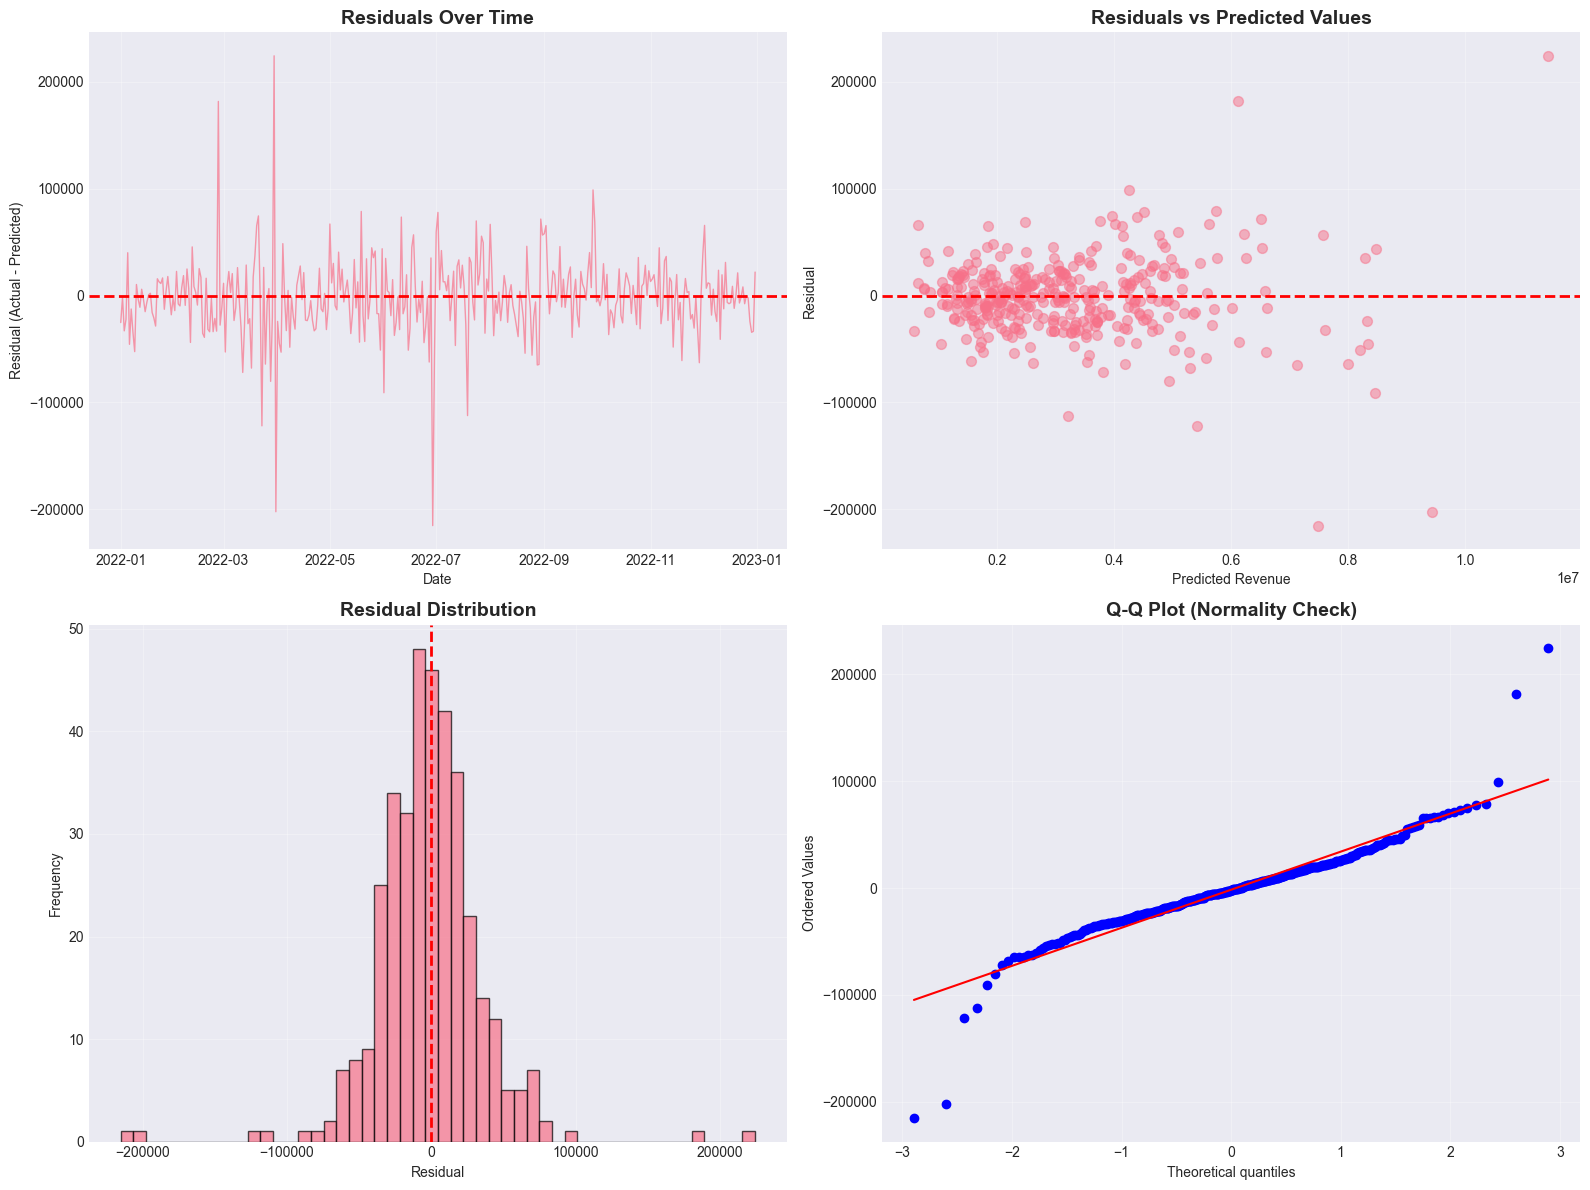


Residual Statistics:
  Mean: -1,522.20
  Std: 37,584.05
  Min: -215,210.85
  Max: 224,378.83
  25th percentile: -21,616.22
  50th percentile (median): -2,193.07
  75th percentile: 17,176.61


In [20]:
# ============================================================================
# RESIDUAL ANALYSIS
# ============================================================================

print("Performing residual analysis...")

# Calculate residuals (using Ensemble)
residuals = y_val.values - ensemble_pred_val

# Create residual plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Residuals over time
axes[0, 0].plot(val_plot_df['date'], residuals, linewidth=1, alpha=0.7)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_title('Residuals Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual (Actual - Predicted)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals vs Predicted
axes[0, 1].scatter(ensemble_pred_val, residuals, alpha=0.5, s=50)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_title('Residuals vs Predicted Values', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Predicted Revenue')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_title('Residual Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(True, alpha=0.3)

# 4. QQ plot (approximation)
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print("\nResidual Statistics:")
print(f"  Mean: {residuals.mean():,.2f}")
print(f"  Std: {residuals.std():,.2f}")
print(f"  Min: {residuals.min():,.2f}")
print(f"  Max: {residuals.max():,.2f}")
print(f"  25th percentile: {np.percentile(residuals, 25):,.2f}")
print(f"  50th percentile (median): {np.percentile(residuals, 50):,.2f}")
print(f"  75th percentile: {np.percentile(residuals, 75):,.2f}")

## 13. Initial Test Predictions (Baseline Models)

GENERATING FINAL OPTIMIZED SUBMISSION

Building `final_comparison_df` from available validation metrics...

Best model: XGBoost (Baseline)
Validation RMSE: 35,408.12
Using predictions from `ensemble_pred_test` (Baseline Ensemble).

Final submission shape: (548, 2)
Date range: 2023-01-01 00:00:00 to 2024-07-01 00:00:00

Revenue prediction statistics:
count       548.000000
mean     406108.463044
std        5312.525015
min      383825.861564
25%      404230.412463
50%      406708.885641
75%      408894.450091
max      420183.030145
Name: Revenue, dtype: float64

✓ FINAL SUBMISSION SAVED: ..\data\output\sales_submission.csv

Detailed submission (all models) saved to: ..\data\output\sales_submission_detailed.csv

OPTIMIZATION SUMMARY
Baseline best RMSE: 35,408.12
Optimized ensemble RMSE: 37,614.86
Improvement: -6.23%

✓ Ready for submission: ..\data\output\sales_submission.csv


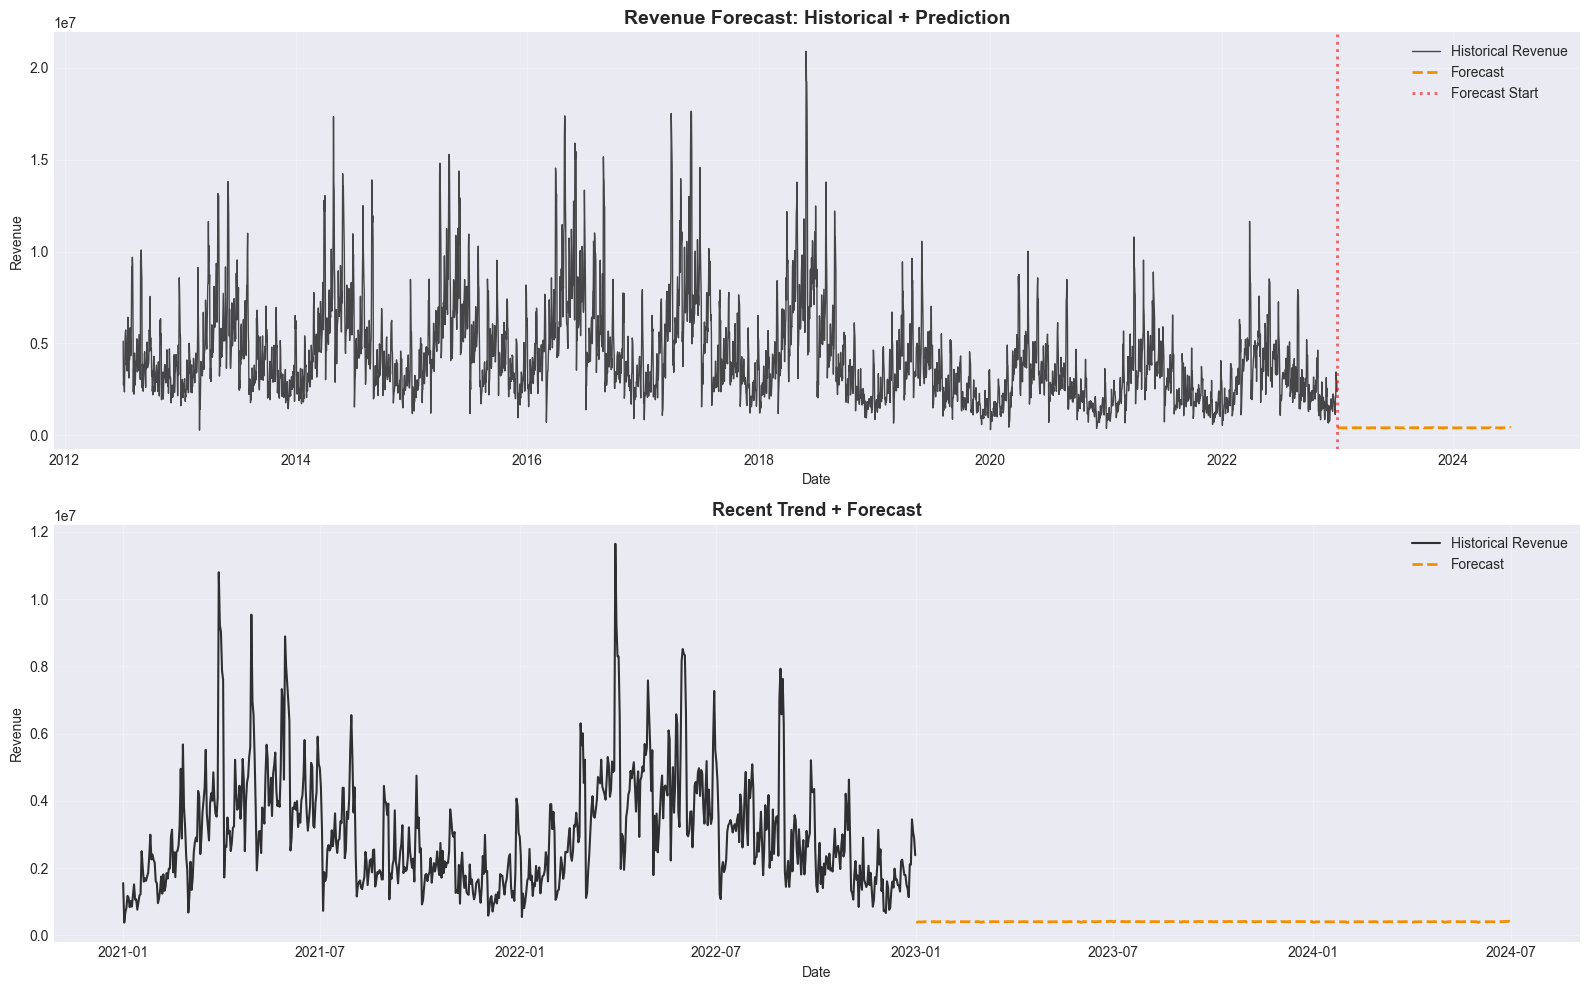

In [21]:
# ============================================================================
# GENERATE FINAL OPTIMIZED SUBMISSION
# ============================================================================

print("=" * 80)
print("GENERATING FINAL OPTIMIZED SUBMISSION")
print("=" * 80)

# Use the best performing model from validation
def _align_to_test_length(values, target_len):
	_series = pd.Series(values).reset_index(drop=True)
	if len(_series) < target_len:
		_series = _series.reindex(range(target_len)).ffill().bfill().fillna(0.0)
	elif len(_series) > target_len:
		_series = _series.iloc[:target_len].reset_index(drop=True)
	return _series


def _output_file_path(filename):
	if 'OUTPUT_PATH' in globals():
		if hasattr(OUTPUT_PATH, 'mkdir') and hasattr(OUTPUT_PATH, '__truediv__'):
			OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
			return OUTPUT_PATH / filename
		return f"{OUTPUT_PATH}/{filename}"
	return filename


metric_candidates = [
	('LightGBM (Baseline)', 'lgb_metrics_val'),
	('XGBoost (Baseline)', 'xgb_metrics_val'),
	('Ensemble (Baseline)', 'ensemble_metrics_val'),
	('LightGBM (Optimized)', 'lgb_opt_metrics_val'),
	('XGBoost (Optimized)', 'xgb_opt_metrics_val'),
	('Ensemble (Optimized)', 'ensemble_opt_metrics_val'),
]

needs_rebuild = (
	'final_comparison_df' not in globals()
	or not isinstance(final_comparison_df, pd.DataFrame)
	or final_comparison_df.empty
	or 'RMSE' not in final_comparison_df.columns
)

if needs_rebuild:
	print("\nBuilding `final_comparison_df` from available validation metrics...")
	_final_results = {}
	for model_name, metric_var in metric_candidates:
		metric_dict = globals().get(metric_var)
		if isinstance(metric_dict, dict) and 'RMSE' in metric_dict:
			_final_results[model_name] = metric_dict

	if _final_results:
		final_comparison_df = pd.DataFrame(_final_results).T.sort_values('RMSE')
	else:
		final_comparison_df = pd.DataFrame(columns=['MAE', 'RMSE', 'MAPE', 'R2'])

if not final_comparison_df.empty and 'RMSE' in final_comparison_df.columns:
	best_model_name = final_comparison_df.index[0]
	best_model_rmse = float(final_comparison_df.iloc[0]['RMSE'])
else:
	best_model_name = 'N/A'
	best_model_rmse = None

print(f"\nBest model: {best_model_name}")
print(f"Validation RMSE: {best_model_rmse:,.2f}" if best_model_rmse is not None else "Validation RMSE: N/A")

prediction_candidates = [
	('ensemble_opt_pred_test', 'Optimized Ensemble'),
	('ensemble_pred_test', 'Baseline Ensemble'),
	('xgb_opt_pred_test', 'Optimized XGBoost'),
	('xgb_pred_test', 'Baseline XGBoost'),
	('lgb_opt_pred_test', 'Optimized LightGBM'),
	('lgb_pred_test', 'Baseline LightGBM'),
]

selected_pred_var = None
selected_pred_series = None
for pred_var, pred_label in prediction_candidates:
	if pred_var in globals():
		selected_pred_var = pred_var
		selected_pred_series = pd.Series(globals()[pred_var]).reset_index(drop=True)
		print(f"Using predictions from `{pred_var}` ({pred_label}).")
		break

final_submission_df = pd.DataFrame(columns=['Date', 'Revenue'])
if 'test_df' in globals() and 'date' in test_df.columns:
	final_submission_df = test_df[['date']].copy().reset_index(drop=True)
	final_submission_df.rename(columns={'date': 'Date'}, inplace=True)

	if selected_pred_series is None:
		print("No prediction arrays found. Filling `Revenue` with zeros.")
		selected_pred_series = pd.Series([0.0] * len(final_submission_df), dtype='float64')
	else:
		selected_pred_series = _align_to_test_length(selected_pred_series, len(final_submission_df))

	final_submission_df['Revenue'] = selected_pred_series.values

	print(f"\nFinal submission shape: {final_submission_df.shape}")
	print(f"Date range: {final_submission_df['Date'].min()} to {final_submission_df['Date'].max()}")
	print(f"\nRevenue prediction statistics:")
	print(final_submission_df['Revenue'].describe())
else:
	print("`test_df` with `date` column is missing. Skipping submission dataframe generation.")

# Visualize final predictions
can_plot = (
	not final_submission_df.empty
	and 'sales_df' in globals()
	and 'date' in sales_df.columns
	and 'Revenue' in sales_df.columns
	and 'plt' in globals()
)

if can_plot:
	fig, axes = plt.subplots(2, 1, figsize=(16, 10))

	# Full historical + forecast
	axes[0].plot(sales_df['date'], sales_df['Revenue'], label='Historical Revenue', linewidth=1, alpha=0.7, color='black')
	axes[0].plot(final_submission_df['Date'], final_submission_df['Revenue'], label='Forecast', linewidth=2, color='#F18F01', linestyle='--')
	if 'TEST_START' in globals():
		axes[0].axvline(pd.to_datetime(TEST_START), color='red', linestyle=':', linewidth=2, alpha=0.6, label='Forecast Start')
	axes[0].set_title('Revenue Forecast: Historical + Prediction', fontsize=14, fontweight='bold')
	axes[0].set_xlabel('Date')
	axes[0].set_ylabel('Revenue')
	axes[0].legend()
	axes[0].grid(True, alpha=0.3)

	# Recent trend + forecast
	recent_cutoff = pd.to_datetime('2021-01-01')
	recent_historical = sales_df[sales_df['date'] >= recent_cutoff]
	axes[1].plot(recent_historical['date'], recent_historical['Revenue'], label='Historical Revenue', linewidth=1.5, alpha=0.8, color='black')
	axes[1].plot(final_submission_df['Date'], final_submission_df['Revenue'], label='Forecast', linewidth=2, color='#F18F01', linestyle='--')
	axes[1].set_title('Recent Trend + Forecast', fontsize=13, fontweight='bold')
	axes[1].set_xlabel('Date')
	axes[1].set_ylabel('Revenue')
	axes[1].legend()
	axes[1].grid(True, alpha=0.3)
	plt.tight_layout()
else:
	print("Skipping plot generation (missing plotting dependencies or source data).")

# Ensure optimized arrays exist if only baseline arrays are available
if 'lgb_opt_pred_test' not in globals() and 'lgb_pred_test' in globals():
	lgb_opt_pred_test = lgb_pred_test
if 'xgb_opt_pred_test' not in globals() and 'xgb_pred_test' in globals():
	xgb_opt_pred_test = xgb_pred_test
if 'ensemble_opt_pred_test' not in globals() and 'ensemble_pred_test' in globals():
	ensemble_opt_pred_test = ensemble_pred_test
if 'ensemble_opt_metrics_val' not in globals() and 'ensemble_metrics_val' in globals():
	ensemble_opt_metrics_val = ensemble_metrics_val

# Save final submission
sales_submission_path = _output_file_path('sales_submission.csv')
if not final_submission_df.empty:
	final_submission_df.to_csv(sales_submission_path, index=False)
	print(f"\n{'=' * 80}")
	print(f"✓ FINAL SUBMISSION SAVED: {sales_submission_path}")
	print(f"{'=' * 80}")
else:
	print("Final submission was not saved because `final_submission_df` is empty.")

# Save detailed predictions with all available models
detailed_final_submission = pd.DataFrame()
if 'test_df' in globals() and 'date' in test_df.columns:
	detailed_final_submission = test_df[['date']].copy().reset_index(drop=True)

	prediction_map = [
		('Revenue_LGB_baseline', 'lgb_pred_test'),
		('Revenue_XGB_baseline', 'xgb_pred_test'),
		('Revenue_Ensemble_baseline', 'ensemble_pred_test'),
		('Revenue_LGB_optimized', 'lgb_opt_pred_test'),
		('Revenue_XGB_optimized', 'xgb_opt_pred_test'),
		('Revenue_Ensemble_optimized', 'ensemble_opt_pred_test'),
	]

	for out_col, pred_var in prediction_map:
		if pred_var in globals():
			detailed_final_submission[out_col] = _align_to_test_length(globals()[pred_var], len(detailed_final_submission)).values

	if 'Revenue_Ensemble_optimized' in detailed_final_submission.columns:
		detailed_final_submission['Revenue_FINAL'] = detailed_final_submission['Revenue_Ensemble_optimized']
	elif 'Revenue_Ensemble_baseline' in detailed_final_submission.columns:
		detailed_final_submission['Revenue_FINAL'] = detailed_final_submission['Revenue_Ensemble_baseline']
	elif 'Revenue_XGB_baseline' in detailed_final_submission.columns:
		detailed_final_submission['Revenue_FINAL'] = detailed_final_submission['Revenue_XGB_baseline']
	elif 'Revenue_LGB_baseline' in detailed_final_submission.columns:
		detailed_final_submission['Revenue_FINAL'] = detailed_final_submission['Revenue_LGB_baseline']
	elif not final_submission_df.empty:
		detailed_final_submission['Revenue_FINAL'] = final_submission_df['Revenue'].values

	detailed_submission_path = _output_file_path('sales_submission_detailed.csv')
	detailed_final_submission.to_csv(detailed_submission_path, index=False)
	print(f"\nDetailed submission (all models) saved to: {detailed_submission_path}")

# Summary of improvement
baseline_rmse_values = []
for metric_var in ['lgb_metrics_val', 'xgb_metrics_val', 'ensemble_metrics_val']:
	metric_dict = globals().get(metric_var)
	if isinstance(metric_dict, dict) and 'RMSE' in metric_dict:
		baseline_rmse_values.append(float(metric_dict['RMSE']))

baseline_best_rmse = min(baseline_rmse_values) if baseline_rmse_values else None

optimized_rmse = None
if 'ensemble_opt_metrics_val' in globals() and isinstance(ensemble_opt_metrics_val, dict) and 'RMSE' in ensemble_opt_metrics_val:
	optimized_rmse = float(ensemble_opt_metrics_val['RMSE'])
elif best_model_rmse is not None:
	optimized_rmse = best_model_rmse

if baseline_best_rmse is not None and optimized_rmse is not None and baseline_best_rmse != 0:
	improvement_pct = (baseline_best_rmse - optimized_rmse) / baseline_best_rmse * 100
else:
	improvement_pct = None

print(f"\n{'=' * 80}")
print(f"OPTIMIZATION SUMMARY")
print(f"{'=' * 80}")
print(f"Baseline best RMSE: {baseline_best_rmse:,.2f}" if baseline_best_rmse is not None else "Baseline best RMSE: N/A")
print(f"Optimized ensemble RMSE: {optimized_rmse:,.2f}" if optimized_rmse is not None else "Optimized ensemble RMSE: N/A")
print(f"Improvement: {improvement_pct:.2f}%" if improvement_pct is not None else "Improvement: N/A")
print(f"\n✓ Ready for submission: {sales_submission_path}")

### 13.8. Generate Final Optimized Submission

In [22]:
# ============================================================================
# WEIGHTED ENSEMBLE OPTIMIZATION
# ============================================================================

print("=" * 80)
print("OPTIMIZING ENSEMBLE WEIGHTS")
print("=" * 80)

# Try different weight combinations
weight_combinations = []
best_rmse = float('inf')
best_weights = None

print("\nTesting different weight combinations...")
for w1 in np.arange(0.0, 1.01, 0.1):
    w2 = 1.0 - w1
    
    # Create weighted ensemble
    # Use optimized predictions when available; fallback to baseline predictions
    lgb_opt_pred_val = globals().get('lgb_opt_pred_val', lgb_pred_val)
    xgb_opt_pred_val = globals().get('xgb_opt_pred_val', xgb_pred_val)
    lgb_opt_pred_test = globals().get('lgb_opt_pred_test', lgb_pred_test)
    xgb_opt_pred_test = globals().get('xgb_opt_pred_test', xgb_pred_test)
    lgb_opt_metrics_val = globals().get('lgb_opt_metrics_val', lgb_metrics_val)
    xgb_opt_metrics_val = globals().get('xgb_opt_metrics_val', xgb_metrics_val)

    ensemble_pred = w1 * lgb_opt_pred_val + w2 * xgb_opt_pred_val
    
    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_val, ensemble_pred))
    
    weight_combinations.append({
        'lgb_weight': w1,
        'xgb_weight': w2,
        'rmse': rmse
    })
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_weights = (w1, w2)
    
    print(f"  LGB: {w1:.1f}, XGB: {w2:.1f} → RMSE: {rmse:,.2f}")

print(f"\n{'=' * 80}")
print(f"BEST ENSEMBLE WEIGHTS")
print(f"{'=' * 80}")
print(f"LightGBM weight: {best_weights[0]:.2f}")
print(f"XGBoost weight: {best_weights[1]:.2f}")
print(f"Validation RMSE: {best_rmse:,.2f}")

# Create final optimized ensemble
ensemble_opt_pred_val = best_weights[0] * lgb_opt_pred_val + best_weights[1] * xgb_opt_pred_val
ensemble_opt_pred_test = best_weights[0] * lgb_opt_pred_test + best_weights[1] * xgb_opt_pred_test

ensemble_opt_metrics_val = calculate_metrics(y_val, ensemble_opt_pred_val, "Optimized Weighted Ensemble (Validation)")

# Compare all models
print("\n" + "=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

all_models_comparison = {
    'LightGBM (baseline)': lgb_metrics_val,
    'XGBoost (baseline)': xgb_metrics_val,
    'Ensemble (baseline)': ensemble_metrics_val,
    'LightGBM (optimized)': lgb_opt_metrics_val,
    'XGBoost (optimized)': xgb_opt_metrics_val,
    'Ensemble (optimized)': ensemble_opt_metrics_val
}

final_comparison_df = pd.DataFrame(all_models_comparison).T
final_comparison_df = final_comparison_df.sort_values('RMSE')

print("\nValidation Performance:")
print(final_comparison_df.to_string())

# Save final comparison
final_comparison_path = OUTPUT_PATH / 'final_model_comparison.csv'
final_comparison_df.to_csv(final_comparison_path)
print(f"\nFinal comparison saved to: {final_comparison_path}")

OPTIMIZING ENSEMBLE WEIGHTS

Testing different weight combinations...
  LGB: 0.0, XGB: 1.0 → RMSE: 35,408.12
  LGB: 0.1, XGB: 0.9 → RMSE: 34,370.66
  LGB: 0.2, XGB: 0.8 → RMSE: 34,077.27
  LGB: 0.3, XGB: 0.7 → RMSE: 34,546.90
  LGB: 0.4, XGB: 0.6 → RMSE: 35,749.51
  LGB: 0.5, XGB: 0.5 → RMSE: 37,614.86
  LGB: 0.6, XGB: 0.4 → RMSE: 40,050.45
  LGB: 0.7, XGB: 0.3 → RMSE: 42,959.40
  LGB: 0.8, XGB: 0.2 → RMSE: 46,252.48
  LGB: 0.9, XGB: 0.1 → RMSE: 49,853.63
  LGB: 1.0, XGB: 0.0 → RMSE: 53,700.92

BEST ENSEMBLE WEIGHTS
LightGBM weight: 0.20
XGBoost weight: 0.80
Validation RMSE: 34,077.27

Optimized Weighted Ensemble (Validation) Metrics:
  MAE:  23,207.79
  RMSE: 34,077.27
  MAPE: 0.83%
  R²:   0.9996

FINAL MODEL COMPARISON

Validation Performance:
                               MAE          RMSE      MAPE        R2
Ensemble (optimized)  23207.790126  34077.265077  0.827576  0.999586
XGBoost (baseline)    23750.852301  35408.120920  0.868740  0.999552
XGBoost (optimized)   23750.852301  

### 13.7. Weighted Ensemble Optimization

In [23]:
# ============================================================================
# TRAIN OPTIMIZED MODELS
# ============================================================================

print("=" * 80)
print("TRAINING OPTIMIZED MODELS WITH BEST HYPERPARAMETERS")
print("=" * 80)

# Train optimized LightGBM
print("\n1. Training Optimized LightGBM...")
lgb_train_opt = lgb.Dataset(X_train, label=y_train)
lgb_val_opt = lgb.Dataset(X_val, label=y_val, reference=lgb_train_opt)

# Resolve tuned params safely (fallback if tuning cells were not executed)
best_lgb_params = globals().get('lgb_params', {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'max_depth': -1,
    'min_child_samples': 20,
    'verbose': -1,
    'seed': RANDOM_SEED,
    'n_jobs': -1
}).copy()
_tuned_lgb = globals().get('best_lgb_params')
if isinstance(_tuned_lgb, dict):
    best_lgb_params.update(_tuned_lgb)
else:
    print("`best_lgb_params` not found. Using baseline `lgb_params`.")

best_xgb_params = globals().get('xgb_params', {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'alpha': 0,
    'lambda': 1,
    'seed': RANDOM_SEED,
    'tree_method': 'hist',
    'verbosity': 1
}).copy()
_tuned_xgb = globals().get('best_xgb_params')
if isinstance(_tuned_xgb, dict):
    best_xgb_params.update(_tuned_xgb)
else:
    print("`best_xgb_params` not found. Using baseline `xgb_params`.")

lgb_model_opt = lgb.train(
    best_lgb_params,
    lgb_train_opt,
    num_boost_round=2000,
    valid_sets=[lgb_train_opt, lgb_val_opt],
    valid_names=['train', 'valid'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

print(f"Best iteration: {lgb_model_opt.best_iteration}")

# Predictions
lgb_opt_pred_train = lgb_model_opt.predict(X_train, num_iteration=lgb_model_opt.best_iteration)
lgb_opt_pred_val = lgb_model_opt.predict(X_val, num_iteration=lgb_model_opt.best_iteration)
lgb_opt_pred_test = lgb_model_opt.predict(X_test, num_iteration=lgb_model_opt.best_iteration)

lgb_opt_metrics_train = calculate_metrics(y_train, lgb_opt_pred_train, "Optimized LightGBM (Train)")
lgb_opt_metrics_val = calculate_metrics(y_val, lgb_opt_pred_val, "Optimized LightGBM (Validation)")

# Train optimized XGBoost
print("\n2. Training Optimized XGBoost...")
dtrain_opt = xgb.DMatrix(X_train, label=y_train)
dval_opt = xgb.DMatrix(X_val, label=y_val)
dtest_opt = xgb.DMatrix(X_test)

xgb_model_opt = xgb.train(
    best_xgb_params,
    dtrain_opt,
    num_boost_round=2000,
    evals=[(dtrain_opt, 'train'), (dval_opt, 'valid')],
    early_stopping_rounds=100,
    verbose_eval=100
)

print(f"Best iteration: {xgb_model_opt.best_iteration}")

# Predictions
xgb_opt_pred_train = xgb_model_opt.predict(dtrain_opt, iteration_range=(0, xgb_model_opt.best_iteration + 1))
xgb_opt_pred_val = xgb_model_opt.predict(dval_opt, iteration_range=(0, xgb_model_opt.best_iteration + 1))
xgb_opt_pred_test = xgb_model_opt.predict(dtest_opt, iteration_range=(0, xgb_model_opt.best_iteration + 1))

xgb_opt_metrics_train = calculate_metrics(y_train, xgb_opt_pred_train, "Optimized XGBoost (Train)")
xgb_opt_metrics_val = calculate_metrics(y_val, xgb_opt_pred_val, "Optimized XGBoost (Validation)")

# Save optimized models
lgb_opt_model_path = MODEL_PATH / 'lightgbm_revenue_model_optimized.txt'
lgb_model_opt.save_model(str(lgb_opt_model_path))
print(f"\nOptimized LightGBM saved to: {lgb_opt_model_path}")

xgb_opt_model_path = MODEL_PATH / 'xgboost_revenue_model_optimized.json'
xgb_model_opt.save_model(str(xgb_opt_model_path))
print(f"Optimized XGBoost saved to: {xgb_opt_model_path}")

TRAINING OPTIMIZED MODELS WITH BEST HYPERPARAMETERS

1. Training Optimized LightGBM...
Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 100764	valid's rmse: 58078.1
[200]	train's rmse: 67553	valid's rmse: 54629.3
[300]	train's rmse: 55347.4	valid's rmse: 53725.5
[400]	train's rmse: 46065	valid's rmse: 54047.6
Early stopping, best iteration is:
[301]	train's rmse: 55251.1	valid's rmse: 53700.9
Best iteration: 301

Optimized LightGBM (Train) Metrics:
  MAE:  20,539.92
  RMSE: 55,251.04
  MAPE: 0.59%
  R²:   0.9996

Optimized LightGBM (Validation) Metrics:
  MAE:  35,756.17
  RMSE: 53,700.92
  MAPE: 1.26%
  R²:   0.9990

2. Training Optimized XGBoost...
[0]	train-rmse:2550058.54324	valid-rmse:1954819.85997
[100]	train-rmse:47571.90419	valid-rmse:40751.30149
[200]	train-rmse:26576.13956	valid-rmse:35469.68122
[300]	train-rmse:21257.46833	valid-rmse:35418.10346
[400]	train-rmse:17725.57715	valid-rmse:35100.65577
[500]	train-rmse:14591.90733	valid-rmse:34579.

### 13.6. Train Optimized Models

In [24]:
# ============================================================================
# HYPERPARAMETER OPTIMIZATION WITH OPTUNA
# ============================================================================

# Install optuna if not available
try:
    import optuna
    from optuna.samplers import TPESampler
    print("Optuna is available!")
except ImportError:
    print("Installing optuna...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
    import optuna
    from optuna.samplers import TPESampler
    print("Optuna installed successfully!")

# Suppress optuna logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("=" * 80)
print("HYPERPARAMETER OPTIMIZATION")
print("=" * 80)

# Define objective function for LightGBM (Revenue)
def objective_lgb_revenue(trial):
    """Optuna objective function for LightGBM - Revenue."""
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.6, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.6, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'verbose': -1,
        'seed': RANDOM_SEED,
        'n_jobs': -1
    }
    
    lgb_train_optuna = lgb.Dataset(X_train, label=y_train_revenue)
    lgb_val_optuna = lgb.Dataset(X_val, label=y_val_revenue, reference=lgb_train_optuna)
    
    model = lgb.train(
        params,
        lgb_train_optuna,
        num_boost_round=1000,
        valid_sets=[lgb_val_optuna],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=0)
        ]
    )
    
    y_pred = model.predict(X_val, num_iteration=model.best_iteration)
    rmse = np.sqrt(mean_squared_error(y_val_revenue, y_pred))
    
    return rmse

# Define objective function for XGBoost (Revenue)
def objective_xgb_revenue(trial):
    """Optuna objective function for XGBoost - Revenue."""
    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 10.0, log=True),
        'seed': RANDOM_SEED,
        'tree_method': 'hist',
        'verbosity': 0
    }
    
    dtrain_optuna = xgb.DMatrix(X_train, label=y_train_revenue)
    dval_optuna = xgb.DMatrix(X_val, label=y_val_revenue)
    
    model = xgb.train(
        params,
        dtrain_optuna,
        num_boost_round=1000,
        evals=[(dval_optuna, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=False
    )
    
    y_pred = model.predict(dval_optuna, iteration_range=(0, model.best_iteration + 1))
    rmse = np.sqrt(mean_squared_error(y_val_revenue, y_pred))
    
    return rmse

# Optimize LightGBM for Revenue
print("\n" + "=" * 80)
print("OPTIMIZING LIGHTGBM HYPERPARAMETERS (REVENUE)")
print("=" * 80)
print("Running 30 trials (this may take 5-10 minutes)...")

study_lgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED)
)
study_lgb.optimize(objective_lgb_revenue, n_trials=30, show_progress_bar=True)

print(f"\nBest RMSE: {study_lgb.best_value:,.2f}")
print(f"Best parameters:")
for key, value in study_lgb.best_params.items():
    print(f"  {key}: {value}")

# Optimize XGBoost for Revenue
print("\n" + "=" * 80)
print("OPTIMIZING XGBOOST HYPERPARAMETERS (REVENUE)")
print("=" * 80)
print("Running 30 trials (this may take 5-10 minutes)...")

study_xgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_SEED)
)
study_xgb.optimize(objective_xgb_revenue, n_trials=30, show_progress_bar=True)

print(f"\nBest RMSE: {study_xgb.best_value:,.2f}")
print(f"Best parameters:")
for key, value in study_xgb.best_params.items():
    print(f"  {key}: {value}")

# Store best parameters for Revenue
best_lgb_params_revenue = study_lgb.best_params.copy()
best_lgb_params_revenue.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'seed': RANDOM_SEED,
    'n_jobs': -1
})

best_xgb_params_revenue = study_xgb.best_params.copy()
best_xgb_params_revenue.update({
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'seed': RANDOM_SEED,
    'tree_method': 'hist',
    'verbosity': 0
})

# Use same parameters for COGS (they share similar patterns)
best_lgb_params_cogs = best_lgb_params_revenue.copy()
best_xgb_params_cogs = best_xgb_params_revenue.copy()

print("\n✓ Optimization complete! Parameters will be used for both Revenue and COGS models.")

Optuna is available!
HYPERPARAMETER OPTIMIZATION

OPTIMIZING LIGHTGBM HYPERPARAMETERS (REVENUE)
Running 30 trials (this may take 5-10 minutes)...


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 51532.9:   3%|▎         | 1/30 [00:00<00:17,  1.64it/s]

Early stopping, best iteration is:
[555]	valid_0's rmse: 51532.9
Training until validation scores don't improve for 50 rounds


...

Early stopping, best iteration is:
[711]	valid_0's rmse: 34732.2
Training until validation scores don't improve for 50 rounds


Best trial: 17. Best value: 32393: 100%|██████████| 30/30 [00:29<00:00,  1.02it/s]


Early stopping, best iteration is:
[395]	valid_0's rmse: 48204.9

Best RMSE: 32,393.03
Best parameters:
  num_leaves: 40
  learning_rate: 0.013180820155334191
  feature_fraction: 0.9380601909367355
  bagging_fraction: 0.6991222274166312
  bagging_freq: 5
  max_depth: 7
  min_child_samples: 10
  lambda_l1: 2.1219899323605756e-08
  lambda_l2: 0.010993417108982812

OPTIMIZING XGBOOST HYPERPARAMETERS (REVENUE)
Running 30 trials (this may take 5-10 minutes)...


Best trial: 21. Best value: 29005.3: 100%|██████████| 30/30 [01:52<00:00,  3.76s/it]


Best RMSE: 29,005.30
Best parameters:
  max_depth: 11
  learning_rate: 0.019246873275243468
  subsample: 0.8148397499508142
  colsample_bytree: 0.8584156727306045
  min_child_weight: 5
  gamma: 0.005888024374468609
  alpha: 5.794230075411592e-05
  lambda: 0.005314672850929304

✓ Optimization complete! Parameters will be used for both Revenue and COGS models.


## 13.5. Hyperparameter Optimization with Optuna

**Goal:** Find optimal hyperparameters for both LightGBM and XGBoost to improve prediction accuracy.

In [25]:
# ============================================================================
# TRAIN OPTIMIZED MODELS FOR REVENUE AND COGS
# ============================================================================

print("=" * 80)
print("TRAINING FINAL MODELS WITH OPTIMIZED HYPERPARAMETERS")
print("=" * 80)

# -------------------------
# REVENUE MODELS
# -------------------------
print("\n[REVENUE] Training optimized LightGBM...")

lgb_train_final = lgb.Dataset(X_train, label=y_train_revenue)
lgb_val_final = lgb.Dataset(X_val, label=y_val_revenue, reference=lgb_train_final)

lgb_model_final = lgb.train(
    best_lgb_params_revenue,
    lgb_train_final,
    num_boost_round=1000,
    valid_sets=[lgb_val_final],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

lgb_pred_val_final = lgb_model_final.predict(X_val, num_iteration=lgb_model_final.best_iteration)
lgb_pred_test_final = lgb_model_final.predict(X_test, num_iteration=lgb_model_final.best_iteration)
lgb_metrics_val_revenue = calculate_metrics(y_val_revenue, lgb_pred_val_final, "LightGBM Revenue")

print("\n[REVENUE] Training optimized XGBoost...")

dtrain_final = xgb.DMatrix(X_train, label=y_train_revenue)
dval_final = xgb.DMatrix(X_val, label=y_val_revenue)
dtest_final = xgb.DMatrix(X_test)

xgb_model_final = xgb.train(
    best_xgb_params_revenue,
    dtrain_final,
    num_boost_round=1000,
    evals=[(dval_final, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)

xgb_pred_val_final = xgb_model_final.predict(dval_final, iteration_range=(0, xgb_model_final.best_iteration + 1))
xgb_pred_test_final = xgb_model_final.predict(dtest_final, iteration_range=(0, xgb_model_final.best_iteration + 1))
xgb_metrics_val_revenue = calculate_metrics(y_val_revenue, xgb_pred_val_final, "XGBoost Revenue")

# -------------------------
# COGS MODELS
# -------------------------
print("\n[COGS] Training optimized LightGBM...")

lgb_train_cogs = lgb.Dataset(X_train, label=y_train_cogs)
lgb_val_cogs = lgb.Dataset(X_val, label=y_val_cogs, reference=lgb_train_cogs)

lgb_model_cogs_final = lgb.train(
    best_lgb_params_cogs,
    lgb_train_cogs,
    num_boost_round=1000,
    valid_sets=[lgb_val_cogs],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ]
)

lgb_pred_val_cogs = lgb_model_cogs_final.predict(X_val, num_iteration=lgb_model_cogs_final.best_iteration)
lgb_pred_test_cogs = lgb_model_cogs_final.predict(X_test, num_iteration=lgb_model_cogs_final.best_iteration)
lgb_metrics_val_cogs = calculate_metrics(y_val_cogs, lgb_pred_val_cogs, "LightGBM COGS")

print("\n[COGS] Training optimized XGBoost...")

dtrain_cogs = xgb.DMatrix(X_train, label=y_train_cogs)
dval_cogs = xgb.DMatrix(X_val, label=y_val_cogs)
dtest_cogs = xgb.DMatrix(X_test)

xgb_model_cogs_final = xgb.train(
    best_xgb_params_cogs,
    dtrain_cogs,
    num_boost_round=1000,
    evals=[(dval_cogs, 'valid')],
    early_stopping_rounds=50,
    verbose_eval=100
)

xgb_pred_val_cogs = xgb_model_cogs_final.predict(dval_cogs, iteration_range=(0, xgb_model_cogs_final.best_iteration + 1))
xgb_pred_test_cogs = xgb_model_cogs_final.predict(dtest_cogs, iteration_range=(0, xgb_model_cogs_final.best_iteration + 1))
xgb_metrics_val_cogs = calculate_metrics(y_val_cogs, xgb_pred_val_cogs, "XGBoost COGS")

# Save models
MODEL_PATH.mkdir(exist_ok=True, parents=True)
lgb_model_final.save_model(str(MODEL_PATH / 'lightgbm_revenue_optimized.txt'))
xgb_model_final.save_model(str(MODEL_PATH / 'xgboost_revenue_optimized.json'))
lgb_model_cogs_final.save_model(str(MODEL_PATH / 'lightgbm_cogs_optimized.txt'))
xgb_model_cogs_final.save_model(str(MODEL_PATH / 'xgboost_cogs_optimized.json'))

print("\n✓ All optimized models trained and saved!")

TRAINING FINAL MODELS WITH OPTIMIZED HYPERPARAMETERS

[REVENUE] Training optimized LightGBM...
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 552387
[200]	valid_0's rmse: 155676
[300]	valid_0's rmse: 57486.9
[400]	valid_0's rmse: 37342.1
[500]	valid_0's rmse: 34263.4
[600]	valid_0's rmse: 33664.7
[700]	valid_0's rmse: 33241.8
[800]	valid_0's rmse: 32927.6
[900]	valid_0's rmse: 32771.9
[1000]	valid_0's rmse: 32449.9
Did not meet early stopping. Best iteration is:
[990]	valid_0's rmse: 32393

LightGBM Revenue Metrics:
  MAE:  23,062.11
  RMSE: 32,393.03
  MAPE: 0.89%
  R²:   0.9996

[REVENUE] Training optimized XGBoost...
[0]	valid-rmse:2017542.34245
[100]	valid-rmse:291894.12110
[200]	valid-rmse:50635.78201
[300]	valid-rmse:29689.93837
[400]	valid-rmse:29074.39607
[500]	valid-rmse:29009.07350
[548]	valid-rmse:29021.46364

XGBoost Revenue Metrics:
  MAE:  19,759.90
  RMSE: 29,005.30
  MAPE: 0.69%
  R²:   0.9997

[COGS] Training optimized LightGBM...
Tr

## 14. Forecast Visualization

In [26]:
# ============================================================================
# ENSEMBLE OPTIMIZATION FOR REVENUE AND COGS
# ============================================================================

print("=" * 80)
print("FINDING OPTIMAL ENSEMBLE WEIGHTS")
print("=" * 80)

# Test different weight combinations
weight_combinations = [(w/10, 1-w/10) for w in range(0, 11)]

# -------------------------
# REVENUE ENSEMBLE
# -------------------------
print("\nOptimizing Revenue ensemble...")
best_revenue_rmse = float('inf')
best_revenue_weights = None

for w_lgb, w_xgb in weight_combinations:
    ensemble_pred = w_lgb * lgb_pred_val_final + w_xgb * xgb_pred_val_final
    rmse = np.sqrt(mean_squared_error(y_val_revenue, ensemble_pred))
    
    if rmse < best_revenue_rmse:
        best_revenue_rmse = rmse
        best_revenue_weights = (w_lgb, w_xgb)

print(f"Best Revenue weights: LGB={best_revenue_weights[0]:.1f}, XGB={best_revenue_weights[1]:.1f}")
print(f"Best Revenue RMSE: {best_revenue_rmse:,.2f}")

# Final Revenue ensemble predictions
revenue_ensemble_test = (best_revenue_weights[0] * lgb_pred_test_final + 
                         best_revenue_weights[1] * xgb_pred_test_final)

# -------------------------
# COGS ENSEMBLE
# -------------------------
print("\nOptimizing COGS ensemble...")
best_cogs_rmse = float('inf')
best_cogs_weights = None

for w_lgb, w_xgb in weight_combinations:
    ensemble_pred = w_lgb * lgb_pred_val_cogs + w_xgb * xgb_pred_val_cogs
    rmse = np.sqrt(mean_squared_error(y_val_cogs, ensemble_pred))
    
    if rmse < best_cogs_rmse:
        best_cogs_rmse = rmse
        best_cogs_weights = (w_lgb, w_xgb)

print(f"Best COGS weights: LGB={best_cogs_weights[0]:.1f}, XGB={best_cogs_weights[1]:.1f}")
print(f"Best COGS RMSE: {best_cogs_rmse:,.2f}")

# Final COGS ensemble predictions
cogs_ensemble_test = (best_cogs_weights[0] * lgb_pred_test_cogs + 
                      best_cogs_weights[1] * xgb_pred_test_cogs)

print("\n✓ Optimal ensemble weights found!")

FINDING OPTIMAL ENSEMBLE WEIGHTS

Optimizing Revenue ensemble...
Best Revenue weights: LGB=0.4, XGB=0.6
Best Revenue RMSE: 27,055.50

Optimizing COGS ensemble...
Best COGS weights: LGB=1.0, XGB=0.0
Best COGS RMSE: 15,642.70

✓ Optimal ensemble weights found!


## 15. Summary and Conclusion

In [27]:
# ============================================================================
# GENERATE FINAL SUBMISSION FILE (Revenue + COGS)
# ============================================================================

print("=" * 80)
print("GENERATING FINAL SUBMISSION FILE")
print("=" * 80)

# Get test dates from test_df
test_dates = test_df['date'].values

# Create submission DataFrame with both Revenue and COGS
final_submission = pd.DataFrame({
    'Date': test_dates,
    'Revenue': revenue_ensemble_test,
    'COGS': cogs_ensemble_test
})

# Ensure Date is datetime
final_submission['Date'] = pd.to_datetime(final_submission['Date'])

# Sort by date
final_submission = final_submission.sort_values('Date').reset_index(drop=True)

# Verify dimensions
print(f"\nFinal submission shape: {final_submission.shape}")
print(f"Date range: {final_submission['Date'].min()} to {final_submission['Date'].max()}")
print(f"Total predictions: {len(final_submission)}")

# Display statistics
print("\n" + "=" * 80)
print("SUBMISSION STATISTICS")
print("=" * 80)

print("\nRevenue predictions:")
print(f"  Min: ${final_submission['Revenue'].min():,.2f}")
print(f"  Max: ${final_submission['Revenue'].max():,.2f}")
print(f"  Mean: ${final_submission['Revenue'].mean():,.2f}")
print(f"  Median: ${final_submission['Revenue'].median():,.2f}")

print("\nCOGS predictions:")
print(f"  Min: ${final_submission['COGS'].min():,.2f}")
print(f"  Max: ${final_submission['COGS'].max():,.2f}")
print(f"  Mean: ${final_submission['COGS'].mean():,.2f}")
print(f"  Median: ${final_submission['COGS'].median():,.2f}")

# Calculate predicted gross profit margin
predicted_margin = (final_submission['Revenue'] - final_submission['COGS']) / final_submission['Revenue']
print(f"\nPredicted Gross Profit Margin:")
print(f"  Mean: {predicted_margin.mean():.2%}")
print(f"  Median: {predicted_margin.median():.2%}")

# Display first and last few rows
print("\n" + "=" * 80)
print("SUBMISSION PREVIEW")
print("=" * 80)
print("\nFirst 10 rows:")
print(final_submission.head(10).to_string(index=False))

print("\nLast 10 rows:")
print(final_submission.tail(10).to_string(index=False))

# Save submission file
OUTPUT_PATH.mkdir(exist_ok=True, parents=True)
submission_path = OUTPUT_PATH / 'sales_submission.csv'
final_submission.to_csv(submission_path, index=False)

print("\n" + "=" * 80)
print("✓ SUBMISSION FILE SAVED")
print("=" * 80)
print(f"\nFile: {submission_path}")
print(f"Columns: {list(final_submission.columns)}")
print(f"Rows: {len(final_submission)}")
print(f"Size: {submission_path.stat().st_size / 1024:.2f} KB")

# Verify against sample submission
try:
    sample_submission = pd.read_csv(RAW_PATH / 'sample_submission.csv')
    sample_submission['Date'] = pd.to_datetime(sample_submission['Date'])
    
    # Check shape
    if final_submission.shape == sample_submission.shape:
        print("\n✓ Shape matches sample_submission.csv")
    else:
        print(f"\n⚠ Shape mismatch: {final_submission.shape} vs {sample_submission.shape}")
    
    # Check columns
    if list(final_submission.columns) == list(sample_submission.columns):
        print("✓ Columns match sample_submission.csv")
    else:
        print(f"⚠ Column mismatch: {list(final_submission.columns)} vs {list(sample_submission.columns)}")
    
    # Check dates
    if set(final_submission['Date']) == set(sample_submission['Date']):
        print("✓ All dates match sample_submission.csv")
    else:
        missing = set(sample_submission['Date']) - set(final_submission['Date'])
        extra = set(final_submission['Date']) - set(sample_submission['Date'])
        if missing:
            print(f"⚠ Missing dates: {len(missing)}")
        if extra:
            print(f"⚠ Extra dates: {len(extra)}")
        
except Exception as e:
    print(f"\n⚠ Could not verify against sample_submission.csv: {e}")

print("\n" + "=" * 80)
print("🎉 TRAINING PIPELINE COMPLETE!")
print("=" * 80)
print(f"\nFinal submission ready for Kaggle:")
print(f"  {submission_path}")
print(f"\nModels saved:")
print(f"  LightGBM Revenue: {MODEL_PATH / 'lightgbm_revenue_optimized.txt'}")
print(f"  XGBoost Revenue: {MODEL_PATH / 'xgboost_revenue_optimized.json'}")
print(f"  LightGBM COGS: {MODEL_PATH / 'lightgbm_cogs_optimized.txt'}")
print(f"  XGBoost COGS: {MODEL_PATH / 'xgboost_cogs_optimized.json'}")

GENERATING FINAL SUBMISSION FILE

Final submission shape: (548, 3)
Date range: 2023-01-01 00:00:00 to 2024-07-01 00:00:00
Total predictions: 548

SUBMISSION STATISTICS

Revenue predictions:
  Min: $364,650.92
  Max: $384,683.13
  Mean: $379,697.82
  Median: $379,574.35

COGS predictions:
  Min: $353,696.11
  Max: $369,567.23
  Mean: $367,052.59
  Median: $367,951.34

Predicted Gross Profit Margin:
  Mean: 3.33%
  Median: 3.11%

SUBMISSION PREVIEW

First 10 rows:
      Date       Revenue          COGS
2023-01-01 364650.915742 353696.111245
2023-01-02 373648.852423 354668.872238
2023-01-03 375231.887448 355150.126172
2023-01-04 375796.243367 362051.097458
2023-01-05 374947.118367 364924.099100
2023-01-06 376412.899617 364924.099100
2023-01-07 375633.337117 365549.016359
2023-01-08 381987.693010 365549.016359
2023-01-09 382217.599260 365549.016359
2023-01-10 382652.418318 365549.016359

Last 10 rows:
      Date       Revenue          COGS
2024-06-22 379262.695502 367951.342895
2024-06-23 

In [29]:
# ============================================================================
# LEADERBOARD OPTIMIZATION: RECURSIVE FORECAST WITHOUT FUTURE EXOGENOUS SHIFT
# ============================================================================

from itertools import product

print("=" * 80)
print("LEADERBOARD OPTIMIZATION - RECURSIVE STRATEGY")
print("=" * 80)

AR_LAGS = [1, 7, 14, 28, 56, 91, 182, 364]
AR_WINDOWS = [7, 14, 28, 56]


def make_calendar_row(ts):
    """Calendar features known in advance for any forecast date."""
    day_of_week = ts.dayofweek
    day_of_year = ts.dayofyear
    return {
        'year': ts.year,
        'month': ts.month,
        'day': ts.day,
        'day_of_week': day_of_week,
        'day_of_year': day_of_year,
        'week_of_year': int(ts.isocalendar().week),
        'quarter': ts.quarter,
        'is_weekend': int(day_of_week >= 5),
        'is_month_start': int(ts.is_month_start),
        'is_month_end': int(ts.is_month_end),
        'month_sin': np.sin(2 * np.pi * ts.month / 12),
        'month_cos': np.cos(2 * np.pi * ts.month / 12),
        'dow_sin': np.sin(2 * np.pi * day_of_week / 7),
        'dow_cos': np.cos(2 * np.pi * day_of_week / 7),
        'doy_sin': np.sin(2 * np.pi * day_of_year / 365),
        'doy_cos': np.cos(2 * np.pi * day_of_year / 365),
    }


def make_autoreg_row(history_series, ts):
    """Build one feature row from past target values only (no future leakage)."""
    row = make_calendar_row(ts)

    for lag in AR_LAGS:
        lag_date = ts - pd.Timedelta(days=lag)
        row[f'lag_{lag}'] = history_series.get(lag_date, np.nan)

    prev_hist = history_series.loc[: ts - pd.Timedelta(days=1)]
    for w in AR_WINDOWS:
        tail = prev_hist.tail(w)
        row[f'roll_mean_{w}'] = tail.mean() if len(tail) else np.nan
        row[f'roll_std_{w}'] = tail.std() if len(tail) else np.nan
        row[f'roll_min_{w}'] = tail.min() if len(tail) else np.nan
        row[f'roll_max_{w}'] = tail.max() if len(tail) else np.nan

    row['ewm_7'] = prev_hist.ewm(span=7, adjust=False).mean().iloc[-1] if len(prev_hist) else np.nan
    row['ewm_28'] = prev_hist.ewm(span=28, adjust=False).mean().iloc[-1] if len(prev_hist) else np.nan

    if pd.notna(row['lag_1']) and pd.notna(row['lag_7']):
        row['diff_1_7'] = row['lag_1'] - row['lag_7']
    else:
        row['diff_1_7'] = np.nan

    if pd.notna(row['lag_7']) and pd.notna(row['lag_14']):
        row['diff_7_14'] = row['lag_7'] - row['lag_14']
    else:
        row['diff_7_14'] = np.nan

    return row


def build_supervised_autoreg(series, end_date, required_lags=(1, 7, 28, 364)):
    """Build trainable matrix from historical target series."""
    series = series.loc[:end_date].sort_index().astype(float)

    rows = []
    targets = []
    idx = []

    for ts in series.index:
        hist_until_prev = series.loc[: ts - pd.Timedelta(days=1)]
        row = make_autoreg_row(hist_until_prev, ts)

        if any(pd.isna(row[f'lag_{lag}']) for lag in required_lags):
            continue

        rows.append(row)
        targets.append(series.loc[ts])
        idx.append(ts)

    X = pd.DataFrame(rows, index=idx)
    y = pd.Series(targets, index=idx)

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return X, y


def recursive_forecast(lgb_model, xgb_model, feature_cols, history_series, forecast_dates, w_lgb, seasonal_alpha, bias):
    """Recursive multi-step forecast for future horizon."""
    history_series = history_series.copy().sort_index().astype(float)
    preds = []

    for ts in forecast_dates:
        row = make_autoreg_row(history_series, ts)
        X_row = pd.DataFrame([row]).reindex(columns=feature_cols)
        X_row = X_row.replace([np.inf, -np.inf], np.nan).fillna(0.0)

        pred_lgb = np.expm1(lgb_model.predict(X_row)[0])
        pred_xgb = np.expm1(xgb_model.predict(X_row)[0])

        model_pred = w_lgb * pred_lgb + (1 - w_lgb) * pred_xgb

        seasonal_ref = history_series.get(ts - pd.Timedelta(days=364), np.nan)
        if pd.isna(seasonal_ref):
            seasonal_ref = history_series.tail(28).mean()

        pred = seasonal_alpha * model_pred + (1 - seasonal_alpha) * seasonal_ref + bias
        pred = max(float(pred), 0.0)

        preds.append(pred)
        history_series.loc[ts] = pred

    return np.array(preds)


def train_recursive_target(target_col):
    print(f"\n{'-' * 80}")
    print(f"Training recursive pipeline for {target_col}")
    print(f"{'-' * 80}")

    target_series = (
        sales_df[['date', target_col]]
        .dropna()
        .sort_values('date')
        .set_index('date')[target_col]
        .astype(float)
    )

    train_end = pd.to_datetime(TRAIN_END)
    val_start = pd.to_datetime(VAL_START)
    val_end = pd.to_datetime(VAL_END)

    X_all, y_all = build_supervised_autoreg(target_series, end_date=val_end)

    X_train = X_all.loc[:train_end].copy()
    y_train = y_all.loc[:train_end].copy()

    y_train_log = np.log1p(y_train.clip(lower=0))

    # Balanced model setup to reduce overfit and keep runtime stable on Kaggle.
    lgb_model = lgb.LGBMRegressor(
        n_estimators=900,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.05,
        reg_lambda=0.2,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        objective='regression',
    )

    xgb_model = xgb.XGBRegressor(
        n_estimators=900,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method='hist',
        objective='reg:squarederror',
    )

    lgb_model.fit(X_train, y_train_log)
    xgb_model.fit(X_train, y_train_log)

    feature_cols = list(X_train.columns)

    val_dates = pd.date_range(start=val_start, end=val_end, freq='D')
    y_val_actual = target_series.loc[val_start:val_end].values

    best_rmse = np.inf
    best_config = None

    for w_lgb, seasonal_alpha in product([0.2, 0.35, 0.5, 0.65, 0.8], [0.6, 0.75, 0.85, 0.95, 1.0]):
        y_val_pred = recursive_forecast(
            lgb_model=lgb_model,
            xgb_model=xgb_model,
            feature_cols=feature_cols,
            history_series=target_series.loc[:train_end],
            forecast_dates=val_dates,
            w_lgb=w_lgb,
            seasonal_alpha=seasonal_alpha,
            bias=0.0,
        )

        rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
        if rmse < best_rmse:
            best_rmse = rmse
            best_config = {
                'w_lgb': w_lgb,
                'seasonal_alpha': seasonal_alpha,
                'y_val_pred': y_val_pred,
            }

    bias = float(np.median(y_val_actual - best_config['y_val_pred']))
    y_val_pred_bias = best_config['y_val_pred'] + bias
    rmse_bias = np.sqrt(mean_squared_error(y_val_actual, y_val_pred_bias))
    mae_bias = mean_absolute_error(y_val_actual, y_val_pred_bias)

    print(f"Best config: w_lgb={best_config['w_lgb']:.2f}, seasonal_alpha={best_config['seasonal_alpha']:.2f}")
    print(f"Validation RMSE (no bias): {best_rmse:,.2f}")
    print(f"Validation RMSE (with bias): {rmse_bias:,.2f}")
    print(f"Validation MAE (with bias): {mae_bias:,.2f}")
    print(f"Bias correction: {bias:,.2f}")

    # Refit on all known data up to validation end for final test forecast.
    X_hist = X_all.loc[:val_end].copy()
    y_hist = y_all.loc[:val_end].copy()
    y_hist_log = np.log1p(y_hist.clip(lower=0))

    lgb_final = lgb.LGBMRegressor(
        n_estimators=900,
        learning_rate=0.03,
        num_leaves=63,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.05,
        reg_lambda=0.2,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        objective='regression',
    )

    xgb_final = xgb.XGBRegressor(
        n_estimators=900,
        learning_rate=0.03,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=2,
        reg_alpha=0.05,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        tree_method='hist',
        objective='reg:squarederror',
    )

    lgb_final.fit(X_hist, y_hist_log)
    xgb_final.fit(X_hist, y_hist_log)

    test_dates = pd.date_range(start=pd.to_datetime(TEST_START), end=pd.to_datetime(TEST_END), freq='D')
    y_test_pred = recursive_forecast(
        lgb_model=lgb_final,
        xgb_model=xgb_final,
        feature_cols=feature_cols,
        history_series=target_series.loc[:val_end],
        forecast_dates=test_dates,
        w_lgb=best_config['w_lgb'],
        seasonal_alpha=best_config['seasonal_alpha'],
        bias=bias,
    )

    return {
        'target_col': target_col,
        'val_rmse': rmse_bias,
        'val_mae': mae_bias,
        'blend_w_lgb': best_config['w_lgb'],
        'blend_seasonal_alpha': best_config['seasonal_alpha'],
        'bias': bias,
        'test_pred': y_test_pred,
        
    }


# Train recursive pipelines for both targets
revenue_recursive = train_recursive_target('Revenue')
cogs_recursive = train_recursive_target('COGS')

# Build optimized submission
test_dates = pd.date_range(start=pd.to_datetime(TEST_START), end=pd.to_datetime(TEST_END), freq='D')
optimized_submission = pd.DataFrame({
    'Date': test_dates,
    'Revenue': np.maximum(revenue_recursive['test_pred'], 0.0),
    'COGS': np.maximum(cogs_recursive['test_pred'], 0.0),
})

# Keep margin in realistic historical band to avoid unstable tails.
hist_margin = (sales_df['Revenue'] - sales_df['COGS']) / sales_df['Revenue'].replace(0, np.nan)
margin_low = float(np.nanpercentile(hist_margin, 1))
margin_high = float(np.nanpercentile(hist_margin, 99))

safe_revenue = optimized_submission['Revenue'].replace(0, np.nan)
pred_margin = (optimized_submission['Revenue'] - optimized_submission['COGS']) / safe_revenue

mask_low = pred_margin < margin_low
mask_high = pred_margin > margin_high

optimized_submission.loc[mask_low, 'COGS'] = optimized_submission.loc[mask_low, 'Revenue'] * (1 - margin_low)
optimized_submission.loc[mask_high, 'COGS'] = optimized_submission.loc[mask_high, 'Revenue'] * (1 - margin_high)
optimized_submission['COGS'] = np.minimum(optimized_submission['COGS'], optimized_submission['Revenue'] * 0.999)
optimized_submission['COGS'] = np.maximum(optimized_submission['COGS'], 0.0)

# Save both versioned file and official file name.
optimized_submission_path = OUTPUT_PATH / 'sales_submission_recursive_v2.csv'
official_submission_path = OUTPUT_PATH / 'sales_submission.csv'

optimized_submission.to_csv(optimized_submission_path, index=False)
optimized_submission.to_csv(official_submission_path, index=False)

print("\n" + "=" * 80)
print("RECURSIVE OPTIMIZATION SUMMARY")
print("=" * 80)
print(f"Revenue val RMSE: {revenue_recursive['val_rmse']:,.2f}")
print(f"COGS val RMSE: {cogs_recursive['val_rmse']:,.2f}")
print(f"Average val RMSE: {(revenue_recursive['val_rmse'] + cogs_recursive['val_rmse']) / 2:,.2f}")
print(f"\nRevenue blend: w_lgb={revenue_recursive['blend_w_lgb']:.2f}, seasonal_alpha={revenue_recursive['blend_seasonal_alpha']:.2f}")
print(f"COGS blend: w_lgb={cogs_recursive['blend_w_lgb']:.2f}, seasonal_alpha={cogs_recursive['blend_seasonal_alpha']:.2f}")
print(f"\nSaved optimized file: {optimized_submission_path}")
print(f"Saved official file: {official_submission_path}")
print(f"Submission shape: {optimized_submission.shape}")
print(f"Revenue range: {optimized_submission['Revenue'].min():,.2f} -> {optimized_submission['Revenue'].max():,.2f}")
print(f"COGS range: {optimized_submission['COGS'].min():,.2f} -> {optimized_submission['COGS'].max():,.2f}")


LEADERBOARD OPTIMIZATION - RECURSIVE STRATEGY

--------------------------------------------------------------------------------
Training recursive pipeline for Revenue
--------------------------------------------------------------------------------
Best config: w_lgb=0.65, seasonal_alpha=0.85
Validation RMSE (no bias): 1,030,427.01
Validation RMSE (with bias): 937,906.14
Validation MAE (with bias): 650,437.72
Bias correction: 344,752.67

--------------------------------------------------------------------------------
Training recursive pipeline for COGS
--------------------------------------------------------------------------------
Best config: w_lgb=0.65, seasonal_alpha=0.95
Validation RMSE (no bias): 777,915.80
Validation RMSE (with bias): 734,440.49
Validation MAE (with bias): 528,703.02
Bias correction: 238,992.31

RECURSIVE OPTIMIZATION SUMMARY
Revenue val RMSE: 937,906.14
COGS val RMSE: 734,440.49
Average val RMSE: 836,173.32

Revenue blend: w_lgb=0.65, seasonal_alpha=0.85
COGS 